Detección de fraude en la apertura de cuentas bancarias

### Machine Learning sensible al coste e interpretabilidad aplicados a la toma de decisiones

**Autor:** Emilio Andrés Navarro Vergara  
**Máster de Formación Permanente en Data Science, Big Data & Business Analytics — UCM, 7.ª edición**  
**Tutores:** Carlos Ortega y Santiago Mota

---

Para el desarrollo del proyecto se utiliza el **Bank Account Fraud (BAF) Suite**, un dataset publicado por Feedzai y presentado en NeurIPS 2022:

Jesus, S. et al. (2022). *Turning the Tables: Biased, Imbalanced, Dynamic Tabular Datasets for ML Evaluation*. NeurIPS 2022. [arXiv:2211.13358](https://arxiv.org/abs/2211.13358)

El dataset se distribuye bajo licencia CC BY-NC-ND 4.0 para uso académico no comercial. Por este motivo, los archivos originales no se incluyen junto con el proyecto. En la Sección 2 se explica cómo obtenerlos y ubicarlos para reproducir el análisis.

**Contenido del notebook:**

0. Configuración del entorno  
1. Contexto del problema  
2. Datos, derechos de uso y auditoría de calidad  
3. Análisis exploratorio  
4. Ingeniería de variables  
5. Modelado predictivo  
6. Evaluación financiera  
7. Interpretabilidad con SHAP  
8. Auditoría de fairness  
9. Productivización  
10. Conclusiones

## 0. Configuración del entorno

Antes de comenzar con el análisis se prepara el entorno de trabajo en Google Colab. En esta sección se instalan las librerías necesarias, se fija la semilla aleatoria, se registran las versiones utilizadas y se crean las carpetas donde se guardarán las figuras, los modelos y los demás resultados del proyecto.

Estas configuraciones buscan que el análisis pueda repetirse posteriormente en condiciones similares.

> **Nota de reproducibilidad:** los resultados presentados en este notebook se obtuvieron con las versiones registradas en la celda 0.2. Para ejecutar el proyecto, el dataset debe descargarse desde Kaggle y guardarse en `MyDrive/TFM_Fraude/data/`.

In [1]:
# Ejecucion del archivo config
%run "config.ipynb"

In [2]:
# Librería estándar
import os
import random
import sys
import warnings
import zipfile
from datetime import datetime

from importlib.metadata import version
import time

# Análisis y tratamiento de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import optuna
import json

import shap

import joblib

print('Librerías cargadas correctamente.')

C:\Users\KRONUS\AppData\Local\Temp\ipykernel_14400\1504398571.py:14: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Librerías cargadas correctamente.


In [3]:
# Revision de versiones
librerias = [
    'numpy', 'pandas', 'matplotlib', 'seaborn', 'scikit-learn',
    'xgboost', 'lightgbm', 'shap', 'optuna', 'joblib'
]

print(f'Python {sys.version.split()[0]}')
print('Entorno registrado el:', datetime.now().strftime('%Y-%m-%d %H:%M'))
print('-' * 40)

for lib in librerias:
    print(f'{lib:<15} {version(lib)}')

Python 3.12.7
Entorno registrado el: 2026-09-16 23:02
----------------------------------------
numpy           1.26.4
pandas          2.2.0
matplotlib      3.8.2
seaborn         0.13.2
scikit-learn    1.6.1
xgboost         2.1.4
lightgbm        4.3.0
shap            0.46.0
optuna          3.5.0
joblib          1.3.2


In [4]:
# Configuración general del proyecto

random.seed(SEED)
np.random.seed(SEED)

# Configuración de la visualización de tablas y números
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_rows', 60)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

warnings.filterwarnings('ignore', category=FutureWarning)

# Estilo común para las figuras del proyecto
sns.set_theme(style='whitegrid', context='notebook')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11

# Creación de directorios necesarios
for ruta in [
    RUTA_LOCAL,
    RUTA_SALIDAS,
    RUTA_FIGURAS,
    RUTA_MODELOS,
    RUTA_REPORTES,
    RUTA_DASH,
    RUTA_PBI,
]:
    ruta.mkdir(parents=True, exist_ok=True)

# Comprobación de la carpeta de datos
assert RUTA_ZIPS.exists(), (
    'No encuentro MyDrive/TFM_Fraude/data. '
    'Revisa el nombre de las carpetas en Drive.'
)

zips = sorted(RUTA_ZIPS.glob('*.zip'))

assert zips, (
    'La carpeta data está vacía. '
    'Sube los archivos zip del dataset.'
)

print('Configuración lista.')
print('  Semilla:', SEED)
print('  Proyecto:', RUTA_PROYECTO)
print('  Zips encontrados:', len(zips))

for z in zips:
    print(f'    - {z.name} ({z.stat().st_size / 1_048_576:.1f} MB)')

Configuración lista.
  Semilla: 42
  Proyecto: c:\Users\KRONUS\Desktop\emilio-master\centinela-fraud-detection
  Zips encontrados: 6
    - Base.csv.zip (82.4 MB)
    - Variant I.csv.zip (82.3 MB)
    - Variant II.csv.zip (82.5 MB)
    - Variant III.csv.zip (101.2 MB)
    - Variant IV.csv.zip (82.5 MB)
    - Variant V.csv.zip (101.2 MB)


## 1. Contexto del problema

El fraude en la apertura de cuentas bancarias, también conocido como *new account fraud*, ocurre cuando una persona solicita una cuenta utilizando información falsa o una identidad robada. Una vez aprobada, la cuenta puede utilizarse para cometer estafas, realizar operaciones ilícitas o generar impagos.

A diferencia del fraude transaccional, en este caso el banco todavía no dispone de un historial de comportamiento del solicitante. La decisión debe tomarse principalmente con la información proporcionada en el formulario y con los datos recogidos durante la sesión de solicitud.

A partir de este problema se desarrolla **CENTINELA**, una propuesta de apoyo a la decisión que estima el riesgo de fraude, evalúa las posibles consecuencias económicas y explica las principales razones detrás de cada alerta. El contexto completo del problema, junto con las cifras del sector y su relación con el entorno ecuatoriano, se desarrolla en la memoria.

## 2. Datos, derechos de uso y auditoría de calidad

El dataset utilizado es el **Bank Account Fraud (BAF) Suite**, publicado por Feedzai y presentado en NeurIPS 2022. Los archivos pueden descargarse desde Kaggle:

https://www.kaggle.com/datasets/sgpjesus/bank-account-fraud-dataset-neurips-2022

El conjunto de datos tiene una licencia CC BY-NC-ND 4.0, que permite su uso académico, pero no su redistribución. Por esta razón, los archivos originales no se incluyen en el proyecto. Para reproducir el análisis, los archivos ZIP deben descargarse desde Kaggle y guardarse, sin descomprimir, en `MyDrive/TFM_Fraude/data/`.

En esta sección se trabaja con el archivo principal, `Base.csv`, que contiene un millón de solicitudes de apertura de cuenta. Primero se descomprime y se carga utilizando tipos de datos ajustados para reducir el consumo de memoria. Después se realizan varias comprobaciones para confirmar sus dimensiones, la distribución de la variable objetivo, el periodo temporal cubierto y la ausencia de registros duplicados.

In [5]:
# Descompresión del dataset
# El archivo se copia desde Drive al almacenamiento local de Colab para agilizar
# la lectura durante la sesión. Si ya fue extraído, no se repite el proceso.

origen = RUTA_ZIPS / NOMBRE_ZIP
destino = RUTA_LOCAL / NOMBRE_CSV

assert origen.exists(), f'No se encontró el archivo: {origen}'

if destino.exists():
    print(f'{NOMBRE_CSV} ya estaba descomprimido.')
else:
    print(f'Descomprimiendo {NOMBRE_ZIP}...')

    with zipfile.ZipFile(origen) as zip_abierto:
        assert NOMBRE_CSV in zip_abierto.namelist(), (
            f'El archivo {NOMBRE_CSV} no se encuentra dentro de {NOMBRE_ZIP}.'
        )

        zip_abierto.extract(NOMBRE_CSV, RUTA_LOCAL)

    print('Archivo descomprimido en:', destino)

print(
    f'Tamaño del archivo: '
    f'{destino.stat().st_size / 1_048_576:.1f} MB'
)

Base.csv ya estaba descomprimido.
Tamaño del archivo: 203.5 MB


In [6]:
# Carga de el millón de filas
inicio = time.time()
df = pd.read_csv(destino, dtype = TIPOS_COLUMNAS)
segundos = time.time() - inicio

memoria_mb = df.memory_usage(deep=True).sum() / 1_048_576

print(f"Dataset cargado en {segundos:.0f} segundos.")
print(f"  Filas: {len(df):,}")
print(f"  Columnas: {df.shape[1]}")
print(f"  Memoria: {memoria_mb:.0f} MB (sin optimizar serían unos 460 MB)")

df.head(3)

Dataset cargado en 2 segundos.
  Filas: 1,000,000
  Columnas: 32
  Memoria: 62 MB (sin optimizar serían unos 460 MB)


,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,employment_status,credit_risk_score,email_is_free,housing_status,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3000,0.9865,-1,25,40,0.0067,102.4537,AA,1059,13096.0352,7850.9551,6742.0806,5,5,CB,163,1,BC,0,1,9,0,1500.0000,0,INTERNET,16.2248,linux,1,1,0,0
1,0,0.8000,0.6174,-1,89,20,0.0101,-0.8496,AD,1658,9223.2832,5745.2515,5941.6650,3,18,CA,154,1,BC,1,1,2,0,1500.0000,0,INTERNET,3.3639,other,1,1,0,0
2,0,0.8000,0.9967,9,14,40,0.0123,-1.4904,AB,1095,4471.4722,5471.9888,5992.5552,15,11,CA,89,1,BC,0,1,30,0,200.0000,0,INTERNET,22.7306,windows,0,1,0,0


In [7]:
# Auditoría inicial del dataset

# El archivo debe contener un millón de solicitudes y 32 columnas.
assert df.shape == (1_000_000, 32), (
    f'Tamaño inesperado: {df.shape}'
)

# La variable objetivo debe contener únicamente solicitudes legítimas y fraudes.
assert set(df['fraud_bool'].unique()) == {0, 1}, (
    'fraud_bool contiene valores distintos de 0 y 1.'
)

# Comprobación del número de fraudes registrado en el dataset.
n_fraudes = int(df['fraud_bool'].sum())

assert n_fraudes == 11_029, (
    f'Se esperaban 11.029 fraudes y se encontraron {n_fraudes:,}.'
)

# El periodo analizado debe incluir los meses del 0 al 7.
meses_esperados = list(range(8))

assert sorted(df['month'].unique()) == meses_esperados, (
    'La variable month contiene periodos faltantes o adicionales.'
)

# El dataset no utiliza NaN; algunos valores ausentes están codificados
# mediante números negativos y se tratarán posteriormente.
assert df.isna().sum().sum() == 0, (
    'Se encontraron valores NaN en el dataset.'
)

# Comprobación de registros completamente duplicados.
assert df.duplicated().sum() == 0, (
    'Se encontraron filas duplicadas.'
)

n_legitimas = len(df) - n_fraudes
tasa_fraude = 100 * n_fraudes / len(df)
ratio_desbalanceo = round(n_legitimas / n_fraudes)

print('Coincide con las características esperadas.')
print(f'  Solicitudes: {len(df):,}')
print(f'  Fraudes: {n_fraudes:,} ({tasa_fraude:.3f}%)')
print(f'  Legítimas: {n_legitimas:,}')
print(f'  Desbalanceo: 1 fraude por cada {ratio_desbalanceo} legítimas')
print(f"  Ventana temporal: meses {df['month'].min()} a {df['month'].max()}")

Coincide con las características esperadas.
  Solicitudes: 1,000,000
  Fraudes: 11,029 (1.103%)
  Legítimas: 988,971
  Desbalanceo: 1 fraude por cada 90 legítimas
  Ventana temporal: meses 0 a 7


In [8]:
# Subconjunto de desarrollo para el análisis exploratorio supervisado
# Se utilizan únicamente los meses 0 a 3.
# El dataset original `df` se mantiene intacto con los meses 0 a 7.

df_dev = df.loc[df['month'] <= 3].copy()

# Comprobaciones
assert set(df_dev['month'].unique()) == {0, 1, 2, 3}
assert len(df_dev) == 547_975

print('Subconjunto de desarrollo creado correctamente.')
print(f'Filas: {len(df_dev):,}')
print(f"Meses incluidos: {df_dev['month'].min()} a {df_dev['month'].max()}")
print(f"Tasa de fraude: {100 * df_dev['fraud_bool'].mean():.3f}%")

Subconjunto de desarrollo creado correctamente.
Filas: 547,975
Meses incluidos: 0 a 3
Tasa de fraude: 0.965%


## 3. Análisis exploratorio de datos

El análisis exploratorio se organiza alrededor de los siguientes cuestionamientos: qué variables contienen valores ausentes y cómo están representados, cómo cambia la tasa de fraude a lo largo del tiempo, qué variables muestran mayores diferencias entre solicitudes legítimas y fraudulentas, y si existen relaciones relevantes entre los predictores.

Para resolverlas se combinan visualizaciones, contrastes estadísticos y el cálculo del Valor de Información. Las figuras generadas se guardan en `outputs/figuras/` para utilizarlas posteriormente en la memoria.

Para evitar que la información de los periodos reservados para validación,
calibración y prueba influya en las decisiones de modelado, los análisis
exploratorios que utilizan la variable objetivo `fraud_bool` se realizan
exclusivamente con los meses 0 a 3. Los meses posteriores se mantienen
fuera de esta fase y se analizan únicamente cuando corresponde según el
esquema temporal definido.

In [9]:
# Función auxiliar para guardar las figuras del análisis

def guardar_figura(fig, nombre):
    """Guarda una figura en la carpeta de resultados."""

    ruta = RUTA_FIGURAS / f'{nombre}.png'
    fig.savefig(ruta, dpi=150, bbox_inches='tight')

    print(f'Figura guardada: {ruta.name}')

In [10]:
# Revisión de los valores que representan información ausente
# El análisis supervisado se realiza únicamente sobre los meses 0-3.

mapa_ausencia = {
    'prev_address_months_count':
        df_dev['prev_address_months_count'] == -1,

    'current_address_months_count':
        df_dev['current_address_months_count'] == -1,

    'bank_months_count':
        df_dev['bank_months_count'] == -1,

    'session_length_in_minutes':
        df_dev['session_length_in_minutes'] == -1,

    'device_distinct_emails_8w':
        df_dev['device_distinct_emails_8w'] == -1,

    'intended_balcon_amount':
        df_dev['intended_balcon_amount'] < 0,
}

filas = []

for col, falta in mapa_ausencia.items():

    tasa_sin = (
        100 * df_dev.loc[falta, 'fraud_bool'].mean()
        if falta.any()
        else np.nan
    )

    tasa_con = (
        100 * df_dev.loc[~falta, 'fraud_bool'].mean()
    )

    filas.append([
        col,
        100 * falta.mean(),
        int(falta.sum()),
        tasa_sin,
        tasa_con
    ])

tabla_ausencia = pd.DataFrame(
    filas,
    columns=[
        'variable',
        'pct_ausente',
        'n_ausente',
        'fraude_si_ausente',
        'fraude_si_presente'
    ]
).sort_values(
    'pct_ausente',
    ascending=False
)

print(tabla_ausencia.to_string(index=False))

# La ausencia de información también parece aportar señal dentro del
# periodo de desarrollo. Por ejemplo, determinadas variables presentan
# tasas de fraude diferentes cuando la información no está disponible.
# Esta relación es descriptiva y no implica causalidad.

fig, ax = plt.subplots(figsize=(9, 4))

orden = tabla_ausencia.sort_values('pct_ausente')

ax.barh(
    orden['variable'],
    orden['pct_ausente'],
    color=COLOR_LEGITIMO
)

ax.set_xlabel('% de solicitudes sin el dato')
ax.set_title(
    'Ausencia por variable — desarrollo meses 0-3'
)

guardar_figura(
    fig,
    'fig_01_ausencias'
)

plt.show()

                    variable  pct_ausente  n_ausente  fraude_si_ausente  fraude_si_presente
      intended_balcon_amount      71.7587     393220             1.1508              0.4930
   prev_address_months_count      68.9004     377557             1.2782              0.2711
           bank_months_count      24.9818     136894             1.4033              0.8191
current_address_months_count       0.4214       2309             0.3032              0.9678
   session_length_in_minutes       0.1816        995             0.9045              0.9651
   device_distinct_emails_8w       0.0412        226             1.3274              0.9649
Figura guardada: fig_01_ausencias.png


<Figure size 990x440 with 1 Axes>

       solicitudes  tasa_fraude
month                          
0           132440       1.1330
1           127620       0.9390
2           136979       0.8750
3           150936       0.9220
Figura guardada: fig_02_evolucion_temporal_desarrollo.png


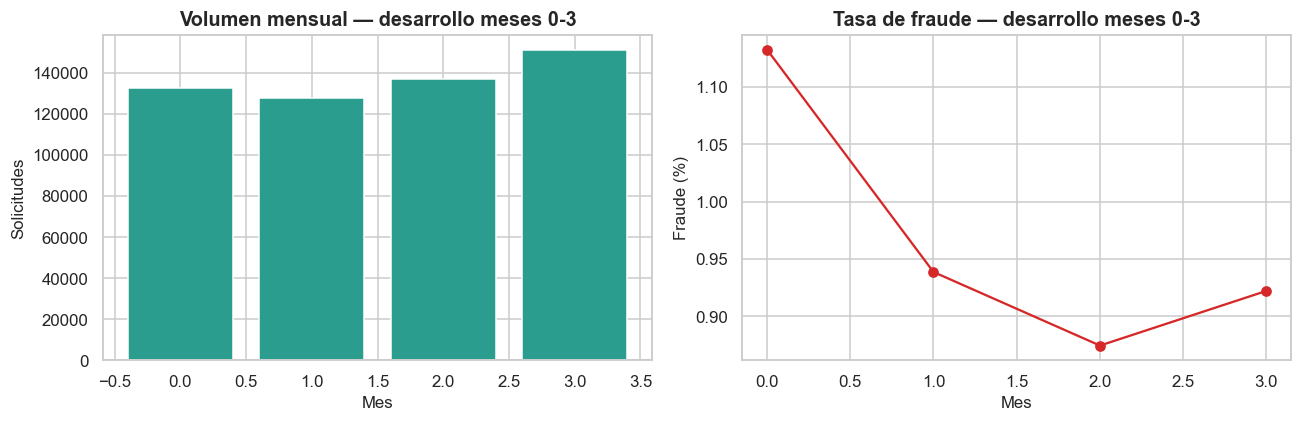

In [11]:
# Evolución temporal observada únicamente durante el periodo de desarrollo
# Los meses posteriores permanecen reservados para validación, calibración y test.

mensual_dev = (
    df_dev.groupby('month')
    .agg(
        solicitudes=('fraud_bool', 'size'),
        tasa_fraude=('fraud_bool', 'mean')
    )
)

mensual_dev['tasa_fraude'] *= 100

print(mensual_dev.round(3).to_string())

fig, ejes = plt.subplots(1, 2, figsize=(12, 4))

# Volumen de solicitudes
ejes[0].bar(
    mensual_dev.index,
    mensual_dev['solicitudes'],
    color=COLOR_LEGITIMO
)

ejes[0].set_title('Volumen mensual — desarrollo meses 0-3')
ejes[0].set_xlabel('Mes')
ejes[0].set_ylabel('Solicitudes')

# Tasa de fraude
ejes[1].plot(
    mensual_dev.index,
    mensual_dev['tasa_fraude'],
    marker='o',
    color=COLOR_FRAUDE
)

ejes[1].set_title('Tasa de fraude — desarrollo meses 0-3')
ejes[1].set_xlabel('Mes')
ejes[1].set_ylabel('Fraude (%)')

fig.tight_layout()

guardar_figura(
    fig,
    'fig_02_evolucion_temporal_desarrollo'
)

plt.show()

                                  mediana_legitimo  mediana_fraude
credit_risk_score                         113.0000        168.0000
name_email_similarity                       0.5100          0.3300
customer_age                               30.0000         40.0000
proposed_credit_limit                     200.0000        500.0000
date_of_birth_distinct_emails_4w           10.0000          7.0000
current_address_months_count               50.0000         89.0000
Figura guardada: fig_03_numericas_por_clase.png


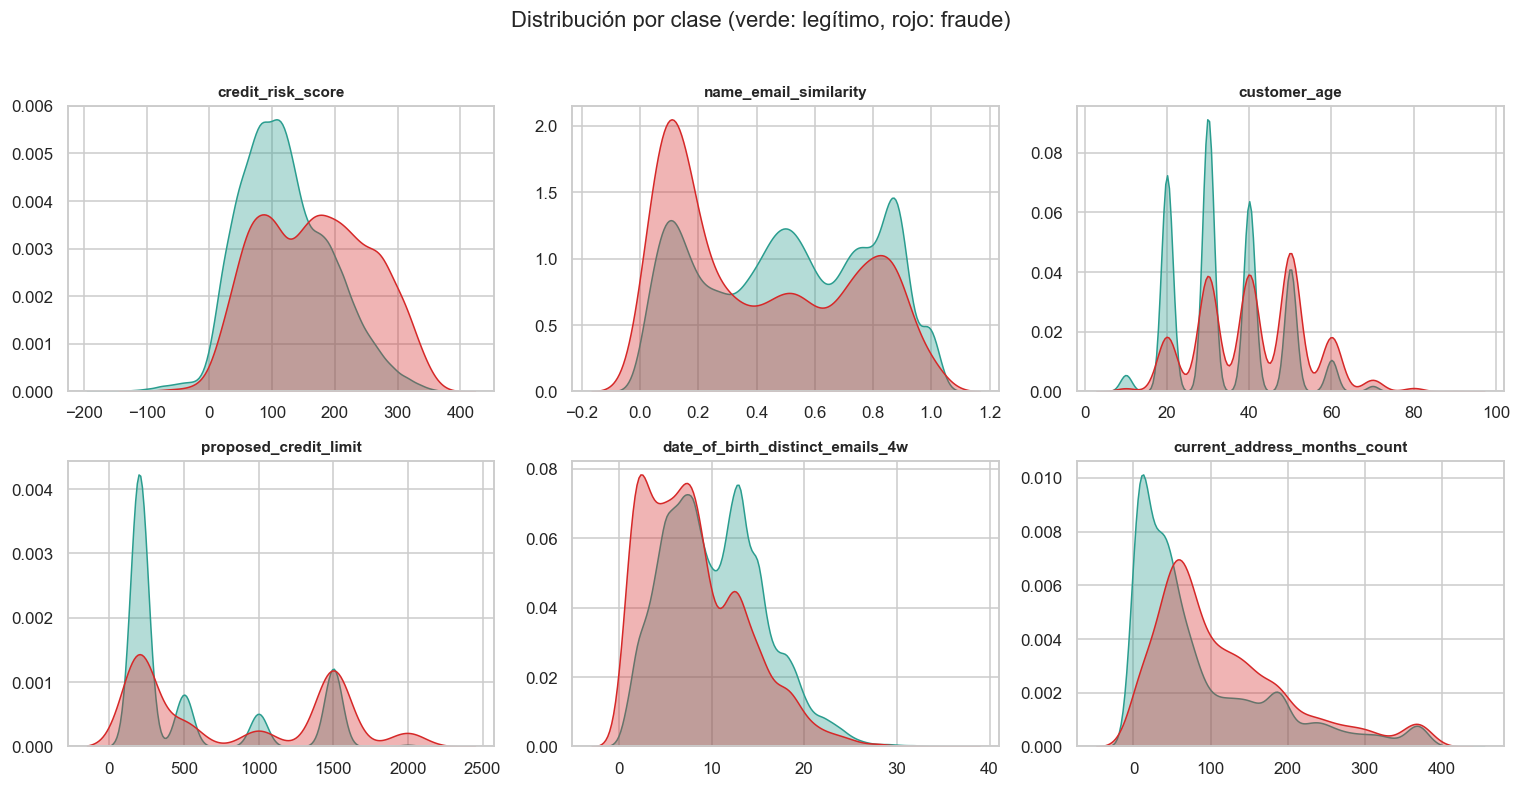

In [12]:
# Se trata el valor -1 como ausencia antes de calcular los estadísticos.
datos_num = df_dev[['fraud_bool'] + VARS_NUM].copy()
datos_num['current_address_months_count'] = (
    datos_num['current_address_months_count'].replace(-1, np.nan)
)

medianas = datos_num.groupby('fraud_bool')[VARS_NUM].median().T
medianas.columns = ['mediana_legitimo', 'mediana_fraude']
print(medianas.round(2).to_string())

# Para agilizar los gráficos se utilizan 50.000 solicitudes legítimas
# y todos los fraudes disponibles.
legitimas_plot = datos_num.loc[datos_num['fraud_bool'] == 0].sample(
    n=50_000,
    random_state=SEED
)

fraudes_plot = datos_num.loc[datos_num['fraud_bool'] == 1]
muestra_plot = pd.concat([legitimas_plot, fraudes_plot])

fig, ejes = plt.subplots(2, 3, figsize=(14, 7))

for ax, col in zip(ejes.ravel(), VARS_NUM):
    for clase, color in PALETA_FRAUDE.items():
        valores = muestra_plot.loc[
            muestra_plot['fraud_bool'] == clase,
            col
        ].dropna()

        sns.kdeplot(
            valores,
            ax=ax,
            color=color,
            fill=True,
            alpha=0.35,
            common_norm=False,
            warn_singular=False
        )

    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('')

fig.suptitle(
    'Distribución por clase (verde: legítimo, rojo: fraude)',
    y=1.02
)
fig.tight_layout()
guardar_figura(fig, 'fig_03_numericas_por_clase')
plt.show()

# Las solicitudes fraudulentas presentan, en términos descriptivos, un mayor
# score de riesgo y límites solicitados más altos, junto con una menor similitud
# entre el nombre y el correo. Estas diferencias muestran asociación, pero no
# deben interpretarse como relaciones causales.

Figura guardada: fig_04_categoricas.png


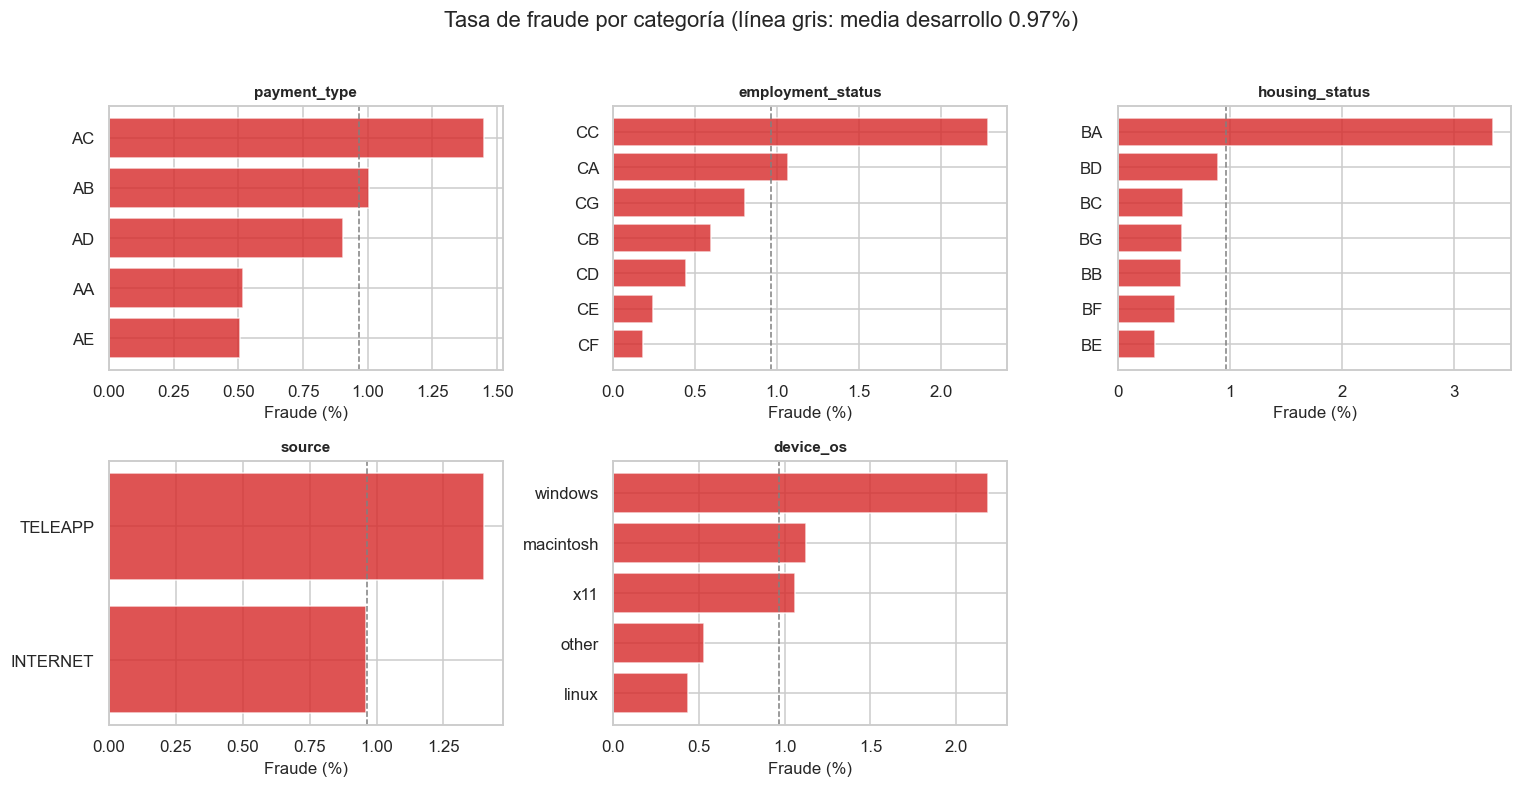

In [13]:
# Comparación de la tasa de fraude entre categorías
# La línea gris representa la tasa media del dataset y permite identificar
# categorías con un comportamiento diferente al conjunto general.

tasa_media = 100 * df_dev['fraud_bool'].mean()

fig, ejes = plt.subplots(2, 3, figsize=(14, 7))

for ax, col in zip(ejes.ravel(), VARS_CAT):
    tasas = (
       100 * df_dev.groupby(col, observed=True)['fraud_bool'].mean()
    ).sort_values()

    ax.barh(
        tasas.index.astype(str),
        tasas.values,
        color=COLOR_FRAUDE,
        alpha=0.8
    )
    ax.axvline(tasa_media, ls='--', c='gray', lw=1)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('Fraude (%)')

ejes.ravel()[-1].axis('off')

fig.suptitle(
    f'Tasa de fraude por categoría '
    f'(línea gris: media desarrollo {tasa_media:.2f}%)',
    y=1.02
)
fig.tight_layout()
guardar_figura(fig, 'fig_04_categoricas')
plt.show()

# Algunas categorías presentan tasas de fraude claramente superiores o inferiores
# a la media global. Estas diferencias sugieren que las variables categóricas
# pueden aportar información útil al modelo, aunque no implican una relación causal.

In [14]:
# Contrastes estadísticos y tamaño del efecto
# Mann-Whitney se utiliza para las variables numéricas y chi-cuadrado para las
# categóricas. Los contrastes se calculan con los meses iniciales de desarrollo.

datos_test = df_dev.copy()

# Estos valores representan información ausente y no deben tratarse como medidas reales.
datos_test['current_address_months_count'] = (
    datos_test['current_address_months_count'].replace(-1, np.nan)
)
datos_test['session_length_in_minutes'] = (
    datos_test['session_length_in_minutes'].replace(-1, np.nan)
)

resultados_test = []

for col in VARS_TEST_NUM:
    x1 = datos_test.loc[datos_test['fraud_bool'] == 1, col].dropna()
    x0 = datos_test.loc[datos_test['fraud_bool'] == 0, col].dropna()

    U, p = stats.mannwhitneyu(
        x1,
        x0,
        alternative='two-sided',
        method='asymptotic'
    )

    rb = 2 * U / (len(x1) * len(x0)) - 1
    resultados_test.append([col, 'Mann-Whitney', p, rb])

for col in VARS_TEST_CAT:
    tabla = pd.crosstab(datos_test[col], datos_test['fraud_bool'])
    chi2, p, _, _ = stats.chi2_contingency(tabla)

    denominador = tabla.values.sum() * (min(tabla.shape) - 1)
    v = np.sqrt(chi2 / denominador) if denominador > 0 else np.nan

    resultados_test.append([col, 'Chi-cuadrado', p, v])

tabla_tests = pd.DataFrame(
    resultados_test,
    columns=['variable', 'test', 'p_valor', 'tam_efecto']
)

# Corrección de Bonferroni por el número de contrastes realizados.
tabla_tests['p_ajustado'] = np.minimum(
    tabla_tests['p_valor'] * len(tabla_tests),
    1
)

tabla_tests['abs_efecto'] = tabla_tests['tam_efecto'].abs()

tabla_tests = tabla_tests.sort_values(
    'abs_efecto',
    ascending=False
)

print(
    tabla_tests
    .drop(columns='abs_efecto')
    .to_string(index=False)
)

# Con una muestra grande, diferencias pequeñas pueden producir p-valores muy bajos.
# Por eso, la interpretación se centra principalmente en el tamaño del efecto.
# Credit_risk_score presenta una de las diferencias más claras, mientras que otras
# variables muestran asociaciones reducidas aunque resulten significativas.

                        variable         test  p_valor  tam_efecto  p_ajustado
                    customer_age Mann-Whitney   0.0000      0.3243      0.0000
               credit_risk_score Mann-Whitney   0.0000      0.3053      0.0000
    current_address_months_count Mann-Whitney   0.0000      0.2790      0.0000
           proposed_credit_limit Mann-Whitney   0.0000      0.2631      0.0000
date_of_birth_distinct_emails_4w Mann-Whitney   0.0000     -0.2602      0.0000
                          income Mann-Whitney   0.0000      0.2580      0.0000
           name_email_similarity Mann-Whitney   0.0000     -0.1906      0.0000
                  housing_status Chi-cuadrado   0.0000      0.1043      0.0000
                       device_os Chi-cuadrado   0.0000      0.0763      0.0000
                    zip_count_4w Mann-Whitney   0.0000      0.0583      0.0000
              keep_alive_session Chi-cuadrado   0.0000      0.0467      0.0000
               employment_status Chi-cuadrado   0.00

housing_status                     0.7480
device_os                          0.5280
current_address_months_count       0.3990
prev_address_months_count          0.3760
customer_age                       0.3610
credit_risk_score                  0.3580
proposed_credit_limit              0.3470
keep_alive_session                 0.2270
date_of_birth_distinct_emails_4w   0.2260
income                             0.2250
employment_status                  0.1800
name_email_similarity              0.1640
has_other_cards                    0.1440
device_distinct_emails_8w          0.1390
payment_type                       0.1350
bank_months_count                  0.1310
intended_balcon_amount             0.1280
bank_branch_count_8w               0.1260
phone_home_valid                   0.0810
email_is_free                      0.0640
days_since_request                 0.0410
phone_mobile_valid                 0.0290
velocity_4w                        0.0220
velocity_24h                      

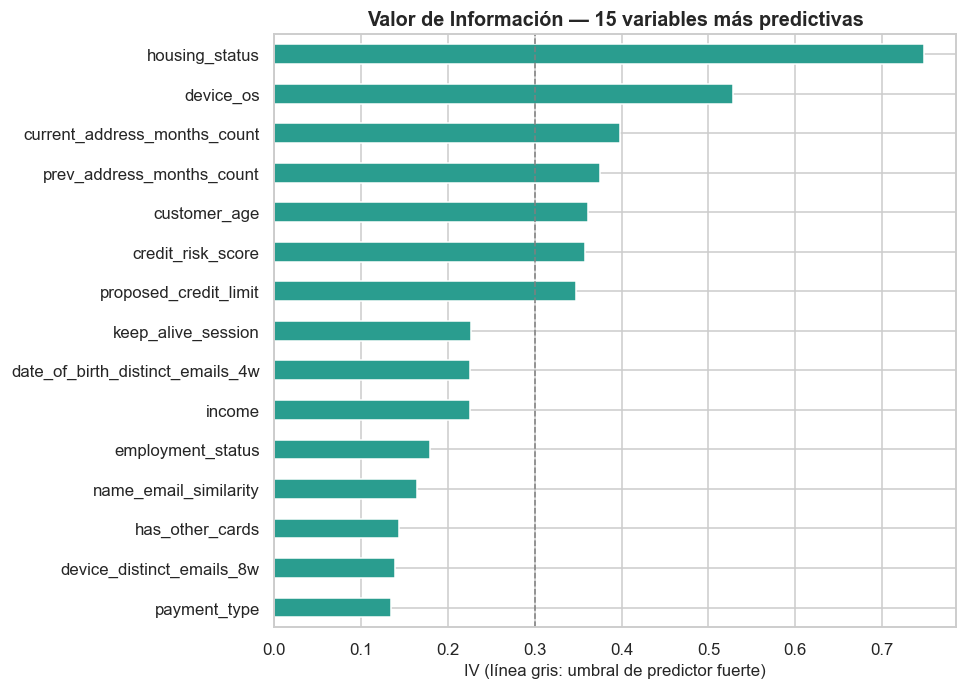

In [15]:
# Cálculo del Valor de Información (WOE/IV)
# Se utiliza únicamente el periodo inicial de desarrollo para evitar que los
# meses posteriores influyan en esta parte del análisis.

def valor_informacion(x, y, bins=10):
    if str(x.dtype) in ('category', 'object', 'str') or x.nunique() <= 10:
        grupos = x.astype('object').where(x.notna(), 'Ausente')
    else:
        grupos = pd.qcut(x, q=bins, duplicates='drop').astype('object')
        grupos = grupos.where(x.notna(), 'Ausente')

    tabla = pd.crosstab(grupos, y)
    if tabla.shape[1] < 2:
        return 0.0

    buenos = (tabla[0] + 0.5) / (tabla[0].sum() + 0.5)
    malos = (tabla[1] + 0.5) / (tabla[1].sum() + 0.5)
    return float(((malos - buenos) * np.log(malos / buenos)).sum())


tmp = df_dev.copy()

# Las ausencias se identifican nuevamente dentro del subconjunto analizado.
ausencias_tmp = {
    'prev_address_months_count' : tmp['prev_address_months_count'] == -1,
    'current_address_months_count' : tmp['current_address_months_count'] == -1,
    'bank_months_count' : tmp['bank_months_count'] == -1,
    'session_length_in_minutes' : tmp['session_length_in_minutes'] == -1,
    'device_distinct_emails_8w' : tmp['device_distinct_emails_8w'] == -1,
    'intended_balcon_amount' : tmp['intended_balcon_amount'] < 0,
}

for col, falta in ausencias_tmp.items():
    tmp[col] = tmp[col].astype('float32').where(~falta)

candidatas = [c for c in tmp.columns
              if c not in ('fraud_bool', 'month', 'device_fraud_count')]

iv = pd.Series({
    c: valor_informacion(tmp[c], tmp['fraud_bool'])
    for c in candidatas
}).sort_values(ascending=False)

print(iv.round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 7))
iv.head(15).iloc[::-1].plot.barh(ax=ax, color=COLOR_LEGITIMO)
ax.axvline(0.3, ls='--', c='gray', lw=1)
ax.set_title('Valor de Información — 15 variables más predictivas')
ax.set_xlabel('IV (línea gris: umbral de predictor fuerte)')
guardar_figura(fig, 'fig_05_iv')
plt.show()

del tmp

# Housing_status y device_os presentan los valores más altos. También destacan
# credit_risk_score, proposed_credit_limit y current_address_months_count.

### Hallazgos del análisis exploratorio

El análisis exploratorio dejó tres conclusiones que influyen directamente en las siguientes etapas del proyecto.

En primer lugar, aunque el dataset no contiene valores nulos convencionales, varias variables utilizan valores negativos para representar información ausente. Estas ausencias aparecen con distinta frecuencia en las solicitudes legítimas y fraudulentas, por lo que se conservarán mediante indicadores específicos.

En segundo lugar, incluso dentro del periodo de desarrollo la tasa de fraude
presenta variaciones temporales. Se sitúa aproximadamente en el 1,13 % en
el mes 0, 0,94 % en el mes 1, 0,87 % en el mes 2 y 0,92 % en el mes 3.
Aunque no se observa una tendencia monotónica dentro de este tramo, estas
fluctuaciones, junto con la naturaleza temporal del problema, justifican
evitar una partición aleatoria de las observaciones. La evolución de los
periodos posteriores se analizará únicamente después de congelar las
decisiones del sistema.

Por último, algunas variables concentran una parte importante de la capacidad predictiva, especialmente `housing_status`, `device_os`, `credit_risk_score` y `proposed_credit_limit`. Las variables de velocidad, en cambio, muestran poca capacidad de separación cuando se analizan de manera aislada, por lo que se explorarán combinaciones entre distintas ventanas temporales.

## 4. Ingeniería de variables

A partir de los resultados del análisis exploratorio se realizan tres transformaciones principales. Primero, los valores que representan información ausente se sustituyen por valores nulos y se acompañan de indicadores que permiten conservar esa señal. Segundo, se crean ratios entre distintas ventanas de velocidad y algunas variables sencillas que resumen condiciones de riesgo observadas en la solicitud. Finalmente, los datos se dividen respetando su orden temporal: los meses 0 a 5 se utilizan para el desarrollo del modelo y los meses 6 y 7 para su evaluación posterior.

In [16]:
# Creación de las variables que se utilizarán en el modelado
# La función se reutiliza durante el entrenamiento, la evaluación y la API.

def construir_features(datos):
    d = datos.copy()

    # Los valores negativos de velocity_6h proceden del generador sintético.
    # Se corrigen antes de construir variables que dependan de ella.
    d['velocity_6h'] = d['velocity_6h'].clip(lower=0)

    # Comparación entre ventanas temporales cortas y largas.
    d['ratio_velocidad_6h_24h'] = (
        d['velocity_6h'] / d['velocity_24h']
    ).astype('float32')

    d['ratio_velocidad_24h_4w'] = (
        d['velocity_24h'] / d['velocity_4w']
    ).astype('float32')

    d['presion_zip'] = (
        d['zip_count_4w'] / d['velocity_4w']
    ).astype('float32')


    for col in RATIOS:
        d[col] = d[col].replace([np.inf, -np.inf], np.nan)

    # Variables que resumen algunas condiciones de la solicitud.
    d['telefonos_validos'] = (
        d['phone_home_valid'] + d['phone_mobile_valid']
    ).astype('int8')

    d['similitud_baja'] = (
        d['name_email_similarity'] < 0.2
    ).astype('int8')

    d['limite_alto'] = (
        d['proposed_credit_limit'] >= 1500
    ).astype('int8')

    d['dispositivo_multiemail'] = (
        d['device_distinct_emails_8w'] >= 2
    ).astype('int8')

    # Cada ausencia se conserva mediante un indicador y el valor pasa a NaN.
    ausencia = {
        'prev_address_months_count' : d['prev_address_months_count'] == -1,
        'current_address_months_count' : d['current_address_months_count'] == -1,
        'bank_months_count' : d['bank_months_count'] == -1,
        'session_length_in_minutes' : d['session_length_in_minutes'] == -1,
        'device_distinct_emails_8w' : d['device_distinct_emails_8w'] == -1,
        'intended_balcon_amount' : d['intended_balcon_amount'] < 0,
    }

    for col, falta in ausencia.items():
        d[col + '_ausente'] = falta.astype('int8')
        d[col] = d[col].astype('float32').where(~falta)

    flags = [c for c in d.columns if c.endswith('_ausente')]
    d['n_faltantes'] = d[flags].sum(axis=1).astype('int8')

    return d

dfm = construir_features(df)

print(
    'Columnas: 32 originales ->',
    dfm.shape[1],
    'tras ingeniería'
)

dev_feat = dfm['month'] <= 3

print(
    'n_faltantes medio (desarrollo 0-3) | legítimo:',
    round(
        dfm.loc[
            dev_feat & (dfm['fraud_bool'] == 0),
            'n_faltantes'
        ].mean(),
        2
    ),
    '| fraude:',
    round(
        dfm.loc[
            dev_feat & (dfm['fraud_bool'] == 1),
            'n_faltantes'
        ].mean(),
        2
    )
)

# Dentro del periodo de desarrollo, las solicitudes fraudulentas
# presentan en promedio más campos ausentes.

Columnas: 32 originales -> 46 tras ingeniería
n_faltantes medio (desarrollo 0-3) | legítimo: 1.66 | fraude: 2.14


In [17]:
# Comprobación de los ratios creados
# Se verifica que las divisiones no hayan generado valores infinitos ni ausentes.
n_inf = int(np.isinf(dfm[RATIOS].to_numpy()).sum())
n_nan = int(dfm[RATIOS].isna().sum().sum())

assert n_inf == 0, (
    f'Se detectaron {n_inf} valores infinitos en los ratios.'
)

assert n_nan == 0, (
    f'Se detectaron {n_nan} valores ausentes en los ratios.'
)

print('Ratios verificados: no se encontraron infinitos ni valores ausentes.')

Ratios verificados: no se encontraron infinitos ni valores ausentes.


In [18]:
# División temporal de los datos y selección de variables

EXCLUIR = ['fraud_bool', 'month', 'device_fraud_count']
predictoras = [c for c in dfm.columns if c not in EXCLUIR]

NUMER = [c for c in predictoras if c not in CATEG]

assert set(CATEG).issubset(predictoras), (
    'Alguna variable categórica no se encuentra entre las predictoras.'
)

tr03 = dfm['month'] <= 3      # Comparación inicial de modelos
v4 = dfm['month'] == 4        # Selección e hiperparámetros
tr04 = dfm['month'] <= 4      # Entrenamiento del modelo definitivo
v5 = dfm['month'] == 5        # Calibración y selección del umbral
te = dfm['month'] >= 6        # Evaluación final

# Comprobación de que los conjuntos de selección, calibración y test no se solapen.
assert not (tr03 & v4).any()
assert not (tr04 & v5).any()
assert not (tr04 & te).any()
assert not (v5 & te).any()
assert (tr04 | v5 | te).all(), 'Hay registros fuera de la división temporal.'

X03, y03 = dfm.loc[tr03, predictoras], dfm.loc[tr03, 'fraud_bool']
X4, y4 = dfm.loc[v4, predictoras], dfm.loc[v4, 'fraud_bool']
X04, y04 = dfm.loc[tr04, predictoras], dfm.loc[tr04, 'fraud_bool']
X5, y5 = dfm.loc[v5, predictoras], dfm.loc[v5, 'fraud_bool']
X_te, y_te = dfm.loc[te, predictoras], dfm.loc[te, 'fraud_bool']

ratio03 = (y03 == 0).sum() / (y03 == 1).sum()
ratio04 = (y04 == 0).sum() / (y04 == 1).sum()

print(f'Desarrollo 0-3: {len(X03):,} filas | fraude: {100*y03.mean():.3f}%')
print(f'Validación mes 4: {len(X4):,} filas | fraude: {100*y4.mean():.3f}%')
print(f'Entrenamiento final 0-4: {len(X04):,} filas | fraude: {100*y04.mean():.3f}%')
print(f'Calibración mes 5: {len(X5):,} filas | fraude: {100*y5.mean():.3f}%')
print(
    f'Test 6-7: {len(X_te):,} filas | '
    'etiquetas reservadas para evaluación final'
)
print(f'Predictoras: {len(predictoras)} '
      f'({len(NUMER)} numéricas, {len(CATEG)} categóricas)')
print(f'Desbalanceo inicial: 1 fraude por cada {ratio03:.0f} legítimas')
print(f'Desbalanceo final: 1 fraude por cada {ratio04:.0f} legítimas')

Desarrollo 0-3: 547,975 filas | fraude: 0.965%
Validación mes 4: 127,691 filas | fraude: 1.137%
Entrenamiento final 0-4: 675,666 filas | fraude: 0.998%
Calibración mes 5: 119,323 filas | fraude: 1.183%
Test 6-7: 205,011 filas | etiquetas reservadas para evaluación final
Predictoras: 43 (38 numéricas, 5 categóricas)
Desbalanceo inicial: 1 fraude por cada 103 legítimas
Desbalanceo final: 1 fraude por cada 99 legítimas


In [19]:
# Librerias para modelos
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, brier_score_loss
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve

In [20]:
# Preparación común de los datos y funciones de evaluación
# Los modelos se entrenan con los meses 0-3 y se comparan en el mes 4.

def hacer_preproc():
    ct = ColumnTransformer(
        [('num', SimpleImputer(strategy='median'), NUMER),
         ('cat', OneHotEncoder(handle_unknown='ignore',
                               sparse_output=False,
                               dtype=np.float32), CATEG)],
        verbose_feature_names_out=False
    )
    ct.set_output(transform='pandas')
    return ct


def tpr_al_fpr(y, s, objetivo=0.05):
    fpr, tpr, _ = roc_curve(y, s)
    return float(np.interp(objetivo, fpr, tpr))

resultados = {}

def evaluar(nombre, pipe):
    t0 = time.time()
    pipe.fit(X03, y03)
    minutos = (time.time() - t0) / 60

    s = pipe.predict_proba(X4)[:, 1]
    resultados[nombre] = {
        'AUC': roc_auc_score(y4, s),
        'AP': average_precision_score(y4, s),
        'Recall@5%FPR': tpr_al_fpr(y4, s),
        'min_entrenamiento': minutos,
    }

    print(nombre, '->', {k: round(v, 4) for k, v in resultados[nombre].items()})

    return pipe, s

print('Marco de evaluación listo.')
print('Entrenamiento: meses 0-3 | Validación: mes 4')

Marco de evaluación listo.
Entrenamiento: meses 0-3 | Validación: mes 4


## 5. Modelado predictivo

El modelado comienza con una regresión logística, que sirve como referencia sencilla e interpretable. Después se prueban Random Forest, XGBoost y LightGBM para comprobar si los modelos basados en árboles consiguen mejorar los resultados.

También se comparan distintas formas de tratar el desbalanceo de clases.
Una vez seleccionado LightGBM como modelo principal, sus hiperparámetros
se ajustan con Optuna utilizando los meses 0 a 3 para el entrenamiento y
el mes 4 para la validación. Una vez fijada la configuración del modelo,
se realiza el entrenamiento definitivo con los meses 0 a 4 y el mes 5 se
reserva para la calibración de probabilidades y la definición del punto
de operación.

Finalmente, las puntuaciones del modelo se calibran mediante regresión isotónica. Este paso es necesario porque, en la siguiente sección, las probabilidades se utilizarán para estimar el coste económico de cada decisión.

In [21]:
# Regresión logística como modelo de referencia
pipe_lr, s_lr = evaluar('Regresión logística', Pipeline([
    ('pre', hacer_preproc()),
    ('escala', StandardScaler()),
    ('modelo', LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    )),
]))

Regresión logística -> {'AUC': 0.9008, 'AP': 0.1462, 'Recall@5%FPR': 0.5331, 'min_entrenamiento': 0.0934}


In [22]:
# Entrenamiento de Random Forest
pipe_rf, s_rf = evaluar('Random Forest', Pipeline([
    ('pre', hacer_preproc()),
    ('modelo', RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=20,
        max_features='sqrt',
        class_weight='balanced_subsample',
        n_jobs=-1,
        random_state=SEED
    )),
]))

Random Forest -> {'AUC': 0.8983, 'AP': 0.1449, 'Recall@5%FPR': 0.522, 'min_entrenamiento': 0.9903}


In [23]:
# Comparación de XGBoost y LightGBM
pipe_xgb, s_xgb = evaluar('XGBoost', Pipeline([
    ('pre', hacer_preproc()),
    ('modelo', XGBClassifier(
        n_estimators=400,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=ratio03,
        tree_method='hist',
        eval_metric='aucpr',
        random_state=SEED,
        n_jobs=-1
    )),
]))

pipe_lgb, s_lgb = evaluar('LightGBM', Pipeline([
    ('pre', hacer_preproc()),
    ('modelo', LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=63,
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.8,
        scale_pos_weight=ratio03,
        random_state=SEED,
        n_jobs=-1,
        verbose=-1
    )),
]))

XGBoost -> {'AUC': 0.8905, 'AP': 0.1562, 'Recall@5%FPR': 0.5262, 'min_entrenamiento': 0.238}
LightGBM -> {'AUC': 0.8946, 'AP': 0.1534, 'Recall@5%FPR': 0.522, 'min_entrenamiento': 0.2572}


In [24]:
# Ajuste de LightGBM con Optuna
# La búsqueda se entrena con los meses 0-3 y se evalúa en el mes 4.
optuna.logging.set_verbosity(optuna.logging.WARNING)

pre_optuna = hacer_preproc().fit(X03)
X03t = pre_optuna.transform(X03)
X4t = pre_optuna.transform(X4)

# Se utiliza otro archivo para no recuperar los parámetros de la búsqueda anterior.
ruta_hp = RUTA_REPORTES / 'mejores_hiperparametros_m4_v2.json'

if ruta_hp.exists():
    with open(ruta_hp, 'r', encoding='utf-8') as f:
        mejores_params = json.load(f)

    print('Hiperparámetros recuperados de Drive:')
    print(mejores_params)

else:
    def objetivo(prueba):
        params = dict(
            n_estimators=prueba.suggest_int('n_estimators', 200, 600),
            learning_rate=prueba.suggest_float(
                'learning_rate', 0.02, 0.2, log=True),
            num_leaves=prueba.suggest_int('num_leaves', 31, 255),
            min_child_samples=prueba.suggest_int(
                'min_child_samples', 20, 200),
            subsample=prueba.suggest_float('subsample', 0.6, 1.0),
            subsample_freq=1,
            colsample_bytree=prueba.suggest_float(
                'colsample_bytree', 0.6, 1.0),
            reg_lambda=prueba.suggest_float('reg_lambda', 0.0, 10.0),
            scale_pos_weight=ratio03,
            random_state=SEED,
            n_jobs=-1,
            verbose=-1
        )

        modelo = LGBMClassifier(**params).fit(X03t, y03)
        s = modelo.predict_proba(X4t)[:, 1]
        return average_precision_score(y4, s)

    estudio = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=SEED)
    )

    estudio.optimize(
        objetivo,
        n_trials=25,
        show_progress_bar=True
    )

    mejores_params = dict(estudio.best_params)

    with open(ruta_hp, 'w', encoding='utf-8') as f:
        json.dump(mejores_params, f, indent=2)

    print('Mejor AP en el mes 4:', round(estudio.best_value, 4))
    print('Mejores hiperparámetros:', mejores_params)

Hiperparámetros recuperados de Drive:
{'n_estimators': 589, 'learning_rate': 0.025483516156873682, 'num_leaves': 62, 'min_child_samples': 200, 'subsample': 0.827788569241047, 'colsample_bytree': 0.768656696446107, 'reg_lambda': 8.753994584269293}


In [25]:
# Comparación de estrategias frente al desbalanceo
# Se prueban tres alternativas con la misma configuración de LightGBM,
# entrenando con los meses 0-3 y evaluando en el mes 4, igual que el resto
# de las decisiones de selección.

def lgb_base(**extra):
    params = dict(
        n_estimators=400,
        learning_rate=0.05,
        num_leaves=63,
        random_state=SEED,
        n_jobs=-1,
        verbose=-1
    )
    params.update(extra)
    return LGBMClassifier(**params)

# Submuestreo: se conservan todos los fraudes y 10 legítimas por cada uno.
fraudes_dev = dfm.loc[tr03 & (dfm['fraud_bool'] == 1)]
legit_dev = dfm.loc[tr03 & (dfm['fraud_bool'] == 0)].sample(
    n=10 * len(fraudes_dev), random_state=SEED)
sub = pd.concat([fraudes_dev, legit_dev]).sample(frac=1, random_state=SEED)

comparativa = {}
for nombre, modelo, (Xa, ya) in [
    ('Sin ajuste', lgb_base(), (X03, y03)),
    ('Ponderación de clases', lgb_base(scale_pos_weight=ratio03), (X03, y03)),
    ('Submuestreo 10:1', lgb_base(), (sub[predictoras], sub['fraud_bool'])),
]:
    p = Pipeline([('pre', hacer_preproc()), ('modelo', modelo)]).fit(Xa, ya)
    s = p.predict_proba(X4)[:, 1]
    comparativa[nombre] = {
        'AUC': roc_auc_score(y4, s),
        'AP': average_precision_score(y4, s),
        'Recall@5%FPR': tpr_al_fpr(y4, s),
    }

print(pd.DataFrame(comparativa).T.round(4).to_string())

                         AUC     AP  Recall@5%FPR
Sin ajuste            0.9042 0.1431        0.5379
Ponderación de clases 0.8897 0.1511        0.5048
Submuestreo 10:1      0.9027 0.1649        0.5406


In [26]:
# Evaluación de la ponderación de clases después de la optimización con Optuna.
# Los hiperparámetros fueron seleccionados usando meses 0-3 para entrenamiento
# y mes 4 como conjunto de selección. Esta evaluación sigue formando parte
# del proceso de selección y no utiliza el test final.

params_opt_ponderado = dict(mejores_params)

params_opt_ponderado.update(
    scale_pos_weight=ratio03,
    subsample_freq=1,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)

modelo_opt_ponderado = LGBMClassifier(
    **params_opt_ponderado
).fit(
    X03t,
    y03
)

s_opt_ponderado = modelo_opt_ponderado.predict_proba(
    X4t
)[:, 1]

metricas_opt_ponderado = {
    'AUC': roc_auc_score(y4, s_opt_ponderado),
    'AP': average_precision_score(y4, s_opt_ponderado),
    'Recall@5%FPR': tpr_al_fpr(y4, s_opt_ponderado),
}

print('LightGBM ponderado después de Optuna — mes 4')
print(
    {
        k: round(v, 4)
        for k, v in metricas_opt_ponderado.items()
    }
)

# Comparación con las tres configuraciones base
comparativa_extendida = pd.DataFrame(comparativa).T.copy()

comparativa_extendida.loc[
    'Ponderación + Optuna'
] = metricas_opt_ponderado

print('\nComparación completa en mes 4:')
print(
    comparativa_extendida
    .sort_values('AP', ascending=False)
    .round(4)
    .to_string()
)

LightGBM ponderado después de Optuna — mes 4
{'AUC': 0.9082, 'AP': 0.1824, 'Recall@5%FPR': 0.5634}

Comparación completa en mes 4:
                         AUC     AP  Recall@5%FPR
Ponderación + Optuna  0.9082 0.1824        0.5634
Submuestreo 10:1      0.9027 0.1649        0.5406
Ponderación de clases 0.8897 0.1511        0.5048
Sin ajuste            0.9042 0.1431        0.5379


### Selección de la estrategia frente al desbalanceo

La comparación inicial muestra que, bajo una configuración base común,
el submuestreo 10:1 obtiene mejores resultados que la ponderación de clases.
Sin embargo, la ponderación se conserva como estrategia de entrenamiento
del modelo final y se optimiza conjuntamente con los hiperparámetros de
LightGBM mediante Optuna, utilizando los meses 0-3 para entrenamiento y el
mes 4 para selección.

Tras la optimización, la configuración ponderada alcanza un AUC de 0,9082,
un Average Precision de 0,1824 y un Recall@5%FPR de 0,5634 en el mes 4,
superando las configuraciones base evaluadas. Por este motivo se adopta
la combinación de ponderación de clases y ajuste de hiperparámetros para
el entrenamiento definitivo.

Brier score: 0.07237 crudo -> 0.01248 calibrado
Figura guardada: fig_07_calibracion.png


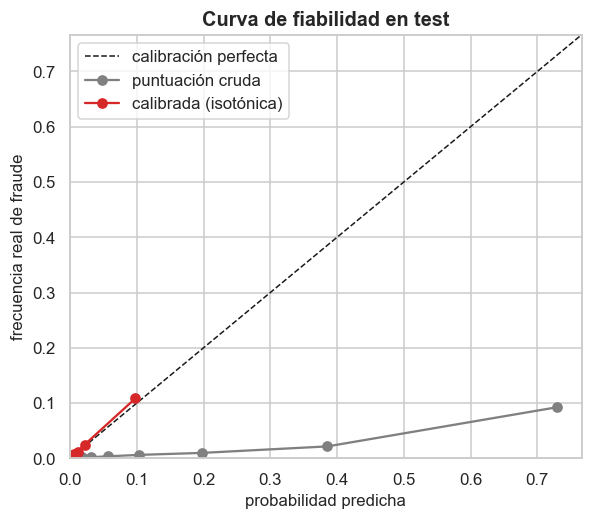


Resultados de selección en el mes 4:
                       AUC     AP  Recall@5%FPR  min_entrenamiento
XGBoost             0.8905 0.1562        0.5262             0.2380
LightGBM            0.8946 0.1534        0.5220             0.2572
Regresión logística 0.9008 0.1462        0.5331             0.0934
Random Forest       0.8983 0.1449        0.5220             0.9903

Resultado final en los meses 6-7:
                            AUC     AP  Recall@5%FPR  Brier
LightGBM final calibrado 0.8891 0.1764        0.5278 0.0125


In [27]:
# Entrenamiento del modelo definitivo y calibración de probabilidades
# El modelo se entrena con los meses 0-4 y se calibra con el mes 5.
pre_fit = hacer_preproc().fit(X04)
X04t = pre_fit.transform(X04)
X5t = pre_fit.transform(X5)
Xtet = pre_fit.transform(X_te)

mejores = dict(mejores_params)
mejores.update(
    scale_pos_weight=ratio04,
    subsample_freq=1,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)

modelo_final = LGBMClassifier(**mejores).fit(X04t, y04)

# El mes 5 se utiliza para ajustar la calibración.
s_val_raw = modelo_final.predict_proba(X5t)[:, 1]
iso = IsotonicRegression(
    out_of_bounds='clip',
    y_min=0,
    y_max=1
).fit(s_val_raw, y5)

p_val = iso.predict(s_val_raw)

# Evaluación final en los meses 6 y 7.
s_test_raw = modelo_final.predict_proba(Xtet)[:, 1]
p_cal = iso.predict(s_test_raw)

metricas_test = {
    'AUC': roc_auc_score(y_te, p_cal),
    'AP': average_precision_score(y_te, p_cal),
    'Recall@5%FPR': tpr_al_fpr(y_te, p_cal),
    'Brier': brier_score_loss(y_te, p_cal),
}

print(f'Brier score: {brier_score_loss(y_te, s_test_raw):.5f} crudo -> '
      f'{brier_score_loss(y_te, p_cal):.5f} calibrado')

frac_pos, media_pred = calibration_curve(
    y_te, p_cal, n_bins=10, strategy='quantile')

frac_pos_raw, media_pred_raw = calibration_curve(
    y_te, s_test_raw, n_bins=10, strategy='quantile')

limite = 1.05 * max(frac_pos.max(), media_pred.max(),
                    frac_pos_raw.max(), media_pred_raw.max())

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, limite], [0, limite], 'k--', lw=1,
        label='calibración perfecta')
ax.plot(media_pred_raw, frac_pos_raw, 'o-', color='gray',
        label='puntuación cruda')
ax.plot(media_pred, frac_pos, 'o-', color=COLOR_FRAUDE,
        label='calibrada (isotónica)')
ax.set_xlim(0, limite)
ax.set_ylim(0, limite)
ax.set_xlabel('probabilidad predicha')
ax.set_ylabel('frecuencia real de fraude')
ax.set_title('Curva de fiabilidad en test')
ax.legend()
guardar_figura(fig, 'fig_07_calibracion')
plt.show()

tabla_validacion = pd.DataFrame(resultados).T.sort_values(
    'AP', ascending=False)

tabla_test = pd.DataFrame(
    [metricas_test],
    index=['LightGBM final calibrado']
)

print('\nResultados de selección en el mes 4:')
print(tabla_validacion.round(4).to_string())

print('\nResultado final en los meses 6-7:')
print(tabla_test.round(4).to_string())

tabla_validacion.to_csv(
    RUTA_REPORTES / 'comparativa_modelos_validacion.csv')

tabla_test.to_csv(
    RUTA_REPORTES / 'metricas_modelo_final_test.csv')

### Decisiones tomadas durante el modelado

**Tratamiento del desbalanceo**

Se decidió no utilizar SMOTE. El dataset ya fue generado de forma sintética y, además, presenta cambios en la tasa de fraude entre meses. Crear nuevos casos mediante interpolación podría añadir combinaciones que no reflejen correctamente la estructura temporal del problema.

También era importante conservar la prevalencia original para calibrar las probabilidades. Por estas razones se compararon tres alternativas más sencillas: no realizar ningún ajuste, ponderar la clase fraudulenta y reducir el número de solicitudes legítimas.

Finalmente se mantuvo la ponderación de clases porque permite utilizar toda la información disponible. Aunque sus resultados iniciales fueron ligeramente inferiores, la diferencia disminuyó después del ajuste de hiperparámetros.

**Elección de LightGBM**

LightGBM se eligió como modelo principal por su velocidad de entrenamiento y por su buen comportamiento en conjuntos tabulares de gran tamaño. En las primeras pruebas no superó a la regresión logística, lo que mostró que utilizar un algoritmo más complejo no garantizaba automáticamente mejores resultados. Aunque sí obtuvo la mejor precisión media (AP), la métrica utilizada para la selección por ser la más adecuada con clases desbalanceadas

Después del ajuste con Optuna, LightGBM obtuvo el mejor resultado entre las configuraciones evaluadas. Por este motivo se utilizó para las etapas posteriores de calibración, evaluación económica e interpretabilidad.

## 6. Evaluación financiera: aprendizaje sensible al coste

Las métricas estadísticas permiten comparar los modelos, pero no reflejan por sí solas el impacto de sus decisiones. En este problema, los dos tipos de error tienen consecuencias diferentes: aprobar una solicitud fraudulenta puede generar una pérdida asociada al límite de crédito solicitado, mientras que enviar una solicitud legítima a revisión implica un coste operativo.

Para representar esta diferencia se asigna un coste de 10 dólares a cada revisión manual y un coste variable a los fraudes no detectados. A partir de estos valores se calcula el ahorro neto del modelo y se estudia cómo cambia según el umbral de decisión.

También se incorpora una restricción sobre el número de alertas que el equipo podría revisar diariamente y se estima un intervalo de confianza para el ahorro obtenido.

Exposición base de fraude (test, 2 meses; severidad 100%): 2,316,970 $ en 2,878 fraudes
Umbral óptimo sin restricciones: 0.0180
  Ahorro: 1,642,950 $ (70.9% de la exposición base)
  Alertas: 37,507 (18.30% de solicitudes) | Recall: 79.8%
Figura guardada: fig_08_curva_ahorro.png


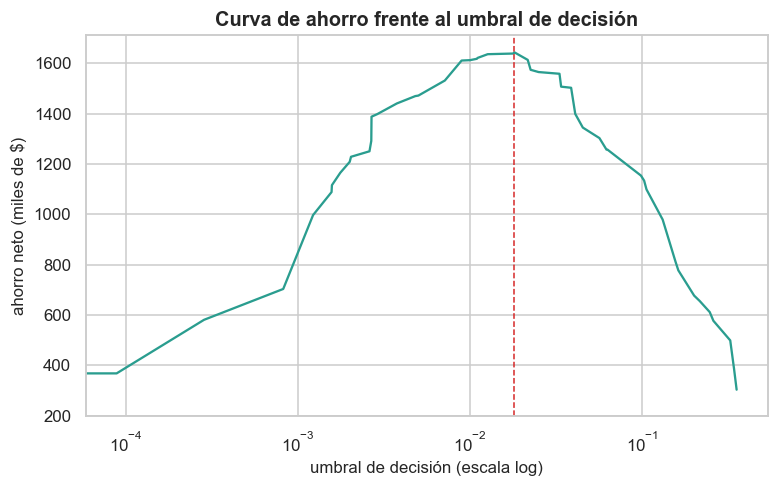

In [28]:
# Cálculo del coste y del ahorro para diferentes umbrales
# Una solicitud se envía a revisión cuando su probabilidad calibrada supera el
# umbral. El coste total combina las revisiones realizadas y los fraudes que el
# modelo deja pasar. Como referencia se utiliza el escenario de aprobar todo.

C_REV = 10.0
y_arr = y_te.to_numpy()
limites = dfm.loc[te, 'proposed_credit_limit'].to_numpy()
edad_te = dfm.loc[te, 'customer_age'].to_numpy()

# Exposición de referencia bajo el supuesto base de severidad del 100 %:
# cada fraude aprobado consume la totalidad del límite de crédito solicitado.
exposicion_fraude_base = limites[y_arr == 1].sum()

print(
    f'Exposición base de fraude '
    f'(test, 2 meses; severidad 100%): '
    f'{exposicion_fraude_base:,.0f} $ '
    f'en {int((y_arr == 1).sum()):,} fraudes'
)

def coste_politica(umbral, p=p_cal):
    alerta = p >= umbral
    coste = C_REV * alerta.sum() + limites[(y_arr == 1) & (~alerta)].sum()
    return coste, alerta

umbrales = np.unique(np.quantile(p_cal, np.linspace(0.001, 0.999, 999)))
ahorros = np.array([
    exposicion_fraude_base - coste_politica(u)[0]
    for u in umbrales
])

i_opt = int(ahorros.argmax())
u_opt = float(umbrales[i_opt])
_, alerta_opt = coste_politica(u_opt)
recall_opt = alerta_opt[y_arr == 1].mean()

print(f'Umbral óptimo sin restricciones: {u_opt:.4f}')
print(f'  Ahorro: {ahorros[i_opt]:,.0f} $ ({100*ahorros[i_opt]/exposicion_fraude_base:.1f}% '
      f'de la exposición base)')
print(f'  Alertas: {alerta_opt.sum():,} ({100*alerta_opt.mean():.2f}% de solicitudes) '
      f'| Recall: {100*recall_opt:.1f}%')

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(umbrales, ahorros / 1000, color=COLOR_LEGITIMO)
ax.axvline(u_opt, ls='--', color=COLOR_FRAUDE, lw=1)
ax.set_xscale('log')
ax.set_xlabel('umbral de decisión (escala log)')
ax.set_ylabel('ahorro neto (miles de $)')
ax.set_title('Curva de ahorro frente al umbral de decisión')
guardar_figura(fig, 'fig_08_curva_ahorro')
plt.show()

# Esta curva permite observar el potencial económico del modelo en el conjunto
# de prueba. Sin embargo, el umbral operativo no se elige a partir de ella:
# en la siguiente celda se fija utilizando únicamente el mes de validación.

In [29]:
# Evaluación del umbral bajo una capacidad limitada de revisión
# Los umbrales se fijan con el mes 5 y después se aplican al test.
DIAS_VAL, DIAS_TEST = 30, 61
vol_dia_val = len(p_val) / DIAS_VAL

filas = []

for capacidad in [50, 150, 300]:
    tasa_obj = capacidad / vol_dia_val

    if not 0 < tasa_obj < 1:
        raise ValueError('La capacidad debe ser menor que el volumen diario.')

    u_k = float(np.quantile(p_val, 1 - tasa_obj))
    c_k, al_k = coste_politica(u_k)

    filas.append([
        capacidad,
        u_k,
        exposicion_fraude_base - c_k,
        100 * al_k[y_arr == 1].mean(),
        al_k.sum() / DIAS_TEST
    ])

tabla_cap = pd.DataFrame(filas, columns=[
    'capacidad_dia',
    'umbral_val',
    'ahorro_test_$',
    'recall_test_%',
    'alertas_dia_test'
])

print(tabla_cap.round(4).to_string(index=False))

U_OPER = float(
    tabla_cap.loc[
        tabla_cap['capacidad_dia'] == 300,
        'umbral_val'
    ].iloc[0]
)

# Se conserva también la decisión del mes 5 para la auditoría de fairness.
alerta_val_oper = p_val >= U_OPER

coste_oper, alerta_oper = coste_politica(U_OPER)
ahorro_oper = exposicion_fraude_base - coste_oper

print(
    f'\nPunto de operación '
    f'(umbral fijado en calibración, mes 5): {U_OPER:.4f}'
)
print(f'Ahorro en test: {ahorro_oper:,.0f} $')
print(f'Alertas/día observadas: {alerta_oper.sum()/DIAS_TEST:,.0f} '
      f'(objetivo 300)')

for coste_revision in [5.0, 20.0]:
    coste = (
        coste_revision * alerta_oper.sum()
        + limites[(y_arr == 1) & (~alerta_oper)].sum()
    )

    print(f'Sensibilidad C_rev={coste_revision:.0f}$ -> '
          f'ahorro {exposicion_fraude_base - coste:,.0f} $')

 capacidad_dia  umbral_val  ahorro_test_$  recall_test_%  alertas_dia_test
            50      0.1313    979170.0000        31.1675           64.7869
           150      0.0564   1302790.0000        47.9152          150.5410
           300      0.0330   1558270.0000        65.9833          337.4590

Punto de operación (umbral fijado en calibración, mes 5): 0.0330
Ahorro en test: 1,558,270 $
Alertas/día observadas: 337 (objetivo 300)
Sensibilidad C_rev=5$ -> ahorro 1,661,195 $
Sensibilidad C_rev=20$ -> ahorro 1,352,420 $


In [30]:
# Estimación de la incertidumbre asociada al ahorro
# El ahorro observado depende de las solicitudes presentes en el conjunto de
# prueba. Para medir su variabilidad se realizan 1.000 remuestreos bootstrap y
# se calcula un intervalo de confianza del 95%. Los resultados se guardan en JSON.
rng = np.random.default_rng(SEED)
n = len(p_cal)
ahorros_boot = np.empty(1000)
for b in range(1000):
    idx = rng.integers(0, n, n)
    pi, yi, li = p_cal[idx], y_arr[idx], limites[idx]
    al = pi >= U_OPER
    ahorros_boot[b] = li[yi == 1].sum() - (C_REV * al.sum() + li[(yi == 1) & (~al)].sum())

ic_bajo, ic_alto = np.percentile(ahorros_boot, [2.5, 97.5])
print(f'Ahorro en el punto de operación: {ahorro_oper:,.0f} $ '
      f'(IC95%: {ic_bajo:,.0f} a {ic_alto:,.0f} $)')

kpis = {
    'exposicion_fraude_base_test_$': float(exposicion_fraude_base),
    'umbral_optimo_teorico': u_opt,
    'ahorro_optimo_teorico_$': float(ahorros[i_opt]),
    'umbral_operacion': U_OPER,
    'ahorro_operacion_$': float(ahorro_oper),
    'ahorro_IC95_$': [float(ic_bajo), float(ic_alto)],
    'coste_revision_$': C_REV,
    'alertas_dia_capacidad': 300,
}
with open(RUTA_REPORTES / 'kpis_financieros.json', 'w') as f:
    json.dump(kpis, f, indent=2)
print('KPIs guardados en', (RUTA_REPORTES / 'kpis_financieros.json').name)

Ahorro en el punto de operación: 1,558,270 $ (IC95%: 1,461,496 a 1,654,212 $)
KPIs guardados en kpis_financieros.json


In [31]:
# Análisis de sensibilidad según la proporción del límite que se pierde
# El escenario principal utiliza el 100% del límite solicitado como exposición.
# Como esa pérdida puede ser menor en la práctica, se repite el cálculo suponiendo
# severidades del 50%, 75% y 100%, manteniendo el mismo umbral operativo.

for lgd in [0.50, 0.75, 1.00]:
    perdida_lgd = lgd * limites[y_arr == 1].sum()
    coste_lgd = C_REV * alerta_oper.sum() + lgd * limites[(y_arr == 1) & (~alerta_oper)].sum()
    print(f'Severidad {int(lgd*100):>3}% -> pérdida evitable {perdida_lgd:,.0f} $ | '
          f'ahorro {perdida_lgd - coste_lgd:,.0f} $')

# El ahorro permanece positivo en los tres escenarios evaluados. A medida que
# disminuye la pérdida asociada a cada fraude, el coste de las revisiones representa
# una proporción mayor del beneficio total obtenido.

Severidad  50% -> pérdida evitable 1,158,485 $ | ahorro 676,210 $
Severidad  75% -> pérdida evitable 1,737,728 $ | ahorro 1,117,240 $
Severidad 100% -> pérdida evitable 2,316,970 $ | ahorro 1,558,270 $


## 7. Interpretabilidad con SHAP

Una vez entrenado el modelo, no basta con conocer su capacidad predictiva. También es necesario entender qué variables influyen con mayor frecuencia en sus decisiones y por qué una solicitud concreta recibe una puntuación de riesgo elevada.

Para ello, la interpretabilidad se analiza desde dos perspectivas. La primera es global y permite identificar las variables más importantes para el modelo y la dirección general de sus efectos. La segunda es local y explica el resultado de una solicitud individual.

A partir de estas explicaciones se construye un informe sencillo que acompaña cada alerta y resume los principales factores que aumentan o reducen el riesgo estimado.

Figura guardada: fig_09_shap_beeswarm.png


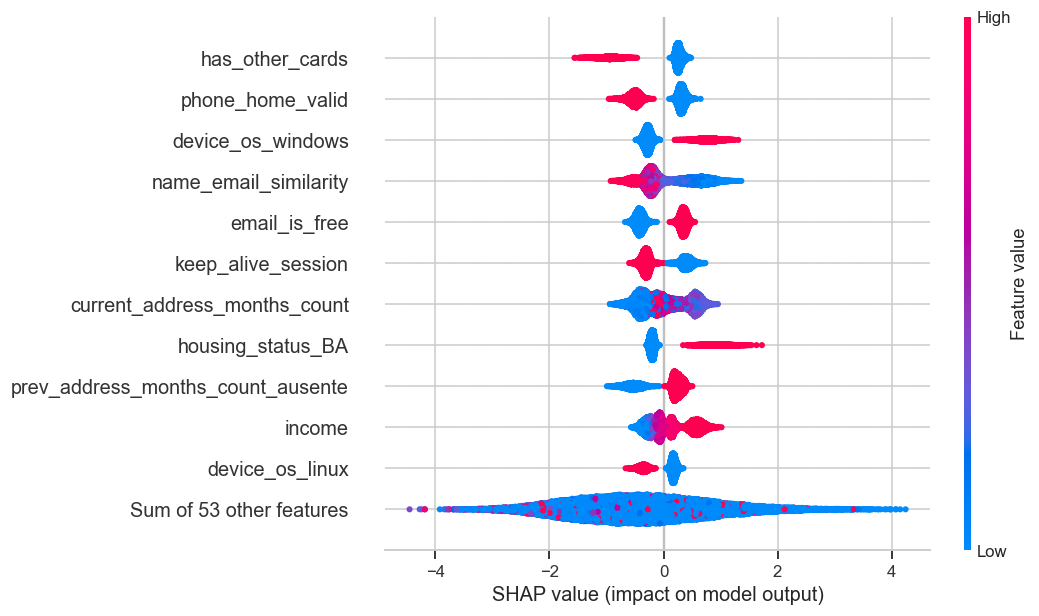

Figura guardada: fig_10_shap_importancia.png


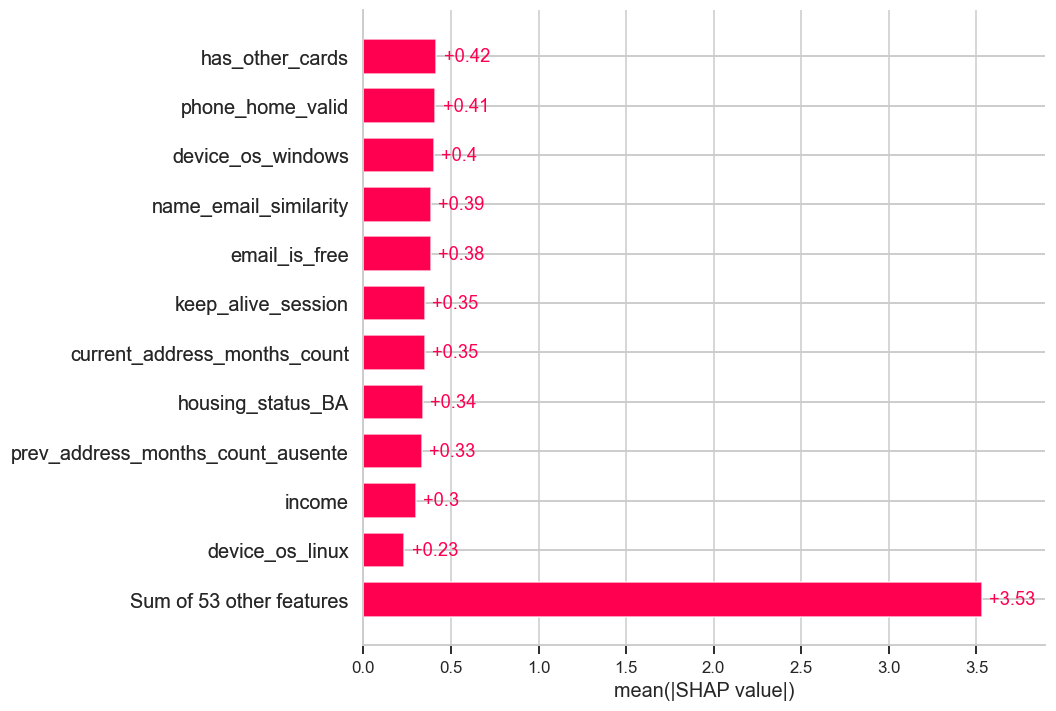

In [32]:
# Análisis global de las variables más influyentes
# Los valores SHAP se calculan sobre una muestra de 20.000 solicitudes del
# conjunto de prueba. El gráfico beeswarm permite observar tanto la importancia
# de cada variable como la dirección de su efecto sobre la predicción.

explicador = shap.TreeExplainer(modelo_final)
muestra = Xtet.sample(20_000, random_state=SEED)
exp_muestra = explicador(muestra)

fig = plt.figure()
shap.plots.beeswarm(exp_muestra, max_display=12, show=False)
guardar_figura(fig, 'fig_09_shap_beeswarm')
plt.show()

fig = plt.figure()
shap.plots.bar(exp_muestra, max_display=12, show=False)
guardar_figura(fig, 'fig_10_shap_importancia')
plt.show()

# Los resultados son consistentes con lo observado durante el análisis
# exploratorio. Entre los factores más relevantes aparecen la situación de
# vivienda, la similitud entre el nombre y el correo, el límite solicitado y
# algunas variables relacionadas con la ausencia de información previa.

Variables continuas dominantes: ['name_email_similarity', 'current_address_months_count', 'bank_branch_count_8w']
Figura guardada: fig_11_dependencia_name_email_similarity.png


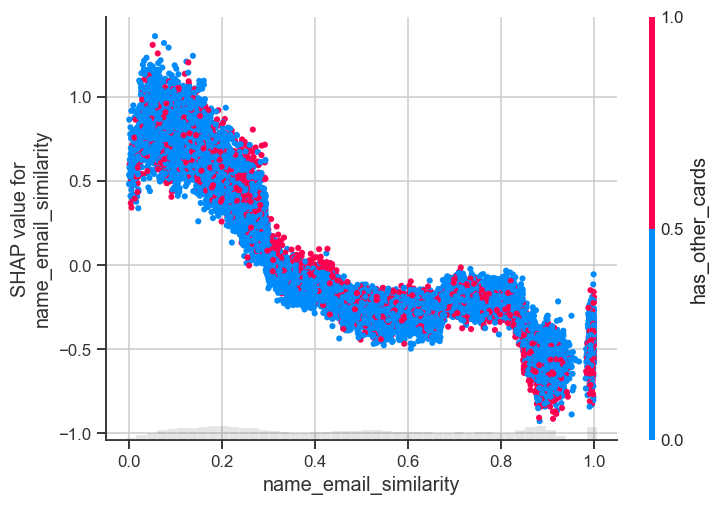

Figura guardada: fig_11_dependencia_current_address_months_count.png


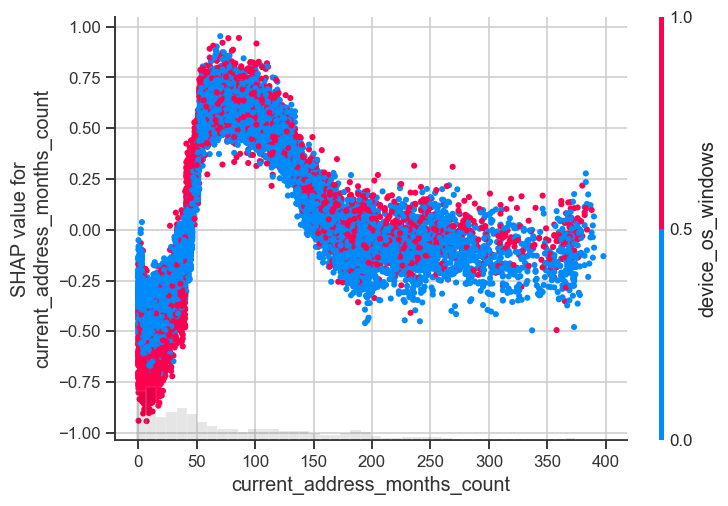

Figura guardada: fig_11_dependencia_bank_branch_count_8w.png


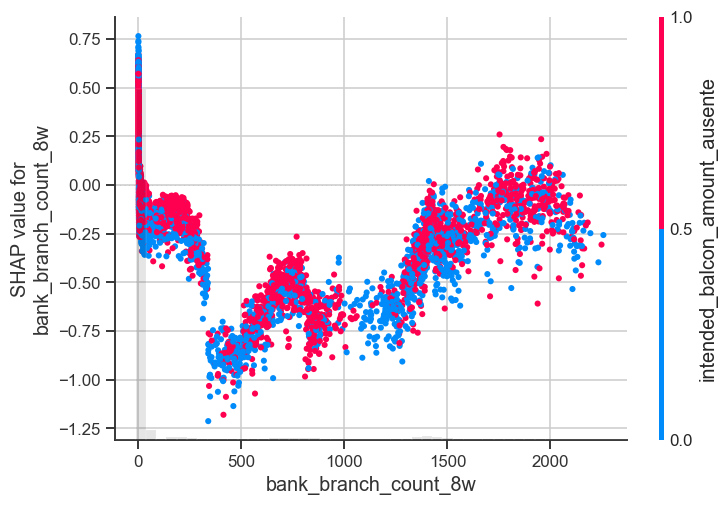

In [33]:
# Efecto de las principales variables numéricas
# Se seleccionan las tres variables continuas con mayor importancia media y se
# representa cómo cambia su contribución a la predicción a lo largo de sus valores.

imp = pd.Series(np.abs(exp_muestra.values).mean(axis=0), index=muestra.columns)
continuas = [c for c in imp.index if muestra[c].nunique() > 10]
top3 = imp[continuas].sort_values(ascending=False).head(3).index.tolist()
print('Variables continuas dominantes:', top3)

for var in top3:
    shap.plots.scatter(exp_muestra[:, var], color=exp_muestra, show=False)
    guardar_figura(plt.gcf(), f'fig_11_dependencia_{var}')
    plt.show()

--- INFORME DE ALERTA · CENTINELA ---
Probabilidad de fraude (calibrada): 5.6%
Exposición si se aprueba: 1,000 $ de límite solicitado
Decisión (0.0330 de umbral): REVISION MANUAL
Factores principales:
  - situación de vivienda tipo BA: aumenta el riesgo (+0.82)
  - similitud entre nombre y correo: aumenta el riesgo (+0.79)
  - nivel de ingresos (decil): aumenta el riesgo (+0.57)
  - puntuación de riesgo crediticio: aumenta el riesgo (+0.48)
Figura guardada: fig_12_waterfall_alerta.png


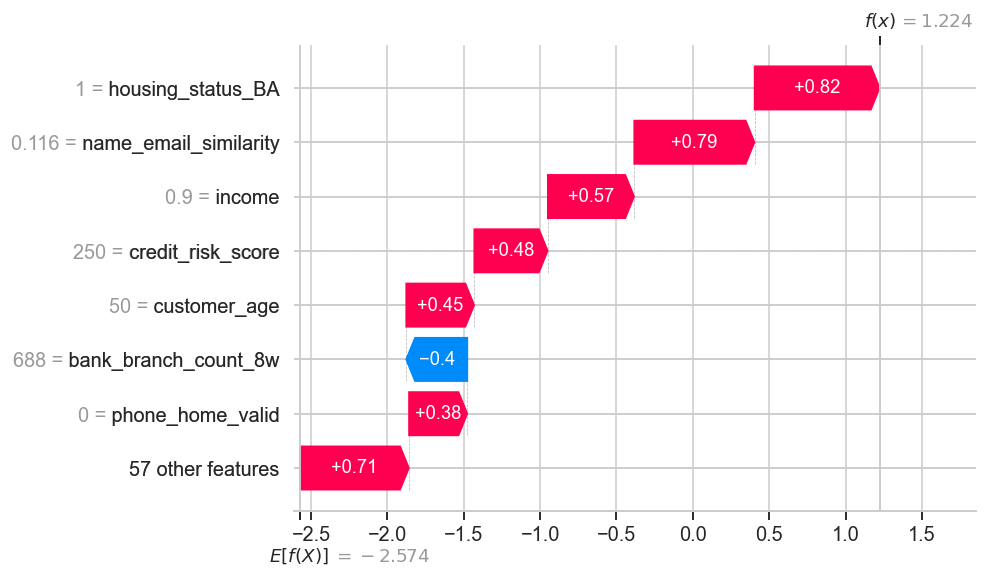

In [34]:
# Creación de un informe para cada solicitud analizada
# Los nombres técnicos de las variables se sustituyen por descripciones más
# fáciles de interpretar. El informe muestra la probabilidad estimada, la
# decisión tomada y los factores que más influyeron en ese resultado.

def nombre_legible(col):
    return NOMBRES_NEGOCIO.get(col, col.replace('_', ' '))

def informe_alerta(pos, top=4):
    exp1 = explicador(Xtet.iloc[[pos]])
    contrib = pd.Series(exp1.values[0], index=Xtet.columns)
    contrib = contrib.sort_values(key=lambda s: s.abs(), ascending=False).head(top)
    prob = p_cal[pos]
    decision = 'REVISION MANUAL' if prob >= U_OPER else 'APROBACION AUTOMATICA'
    print(f'--- INFORME DE ALERTA · CENTINELA ---')
    print(f'Probabilidad de fraude (calibrada): {100*prob:.1f}%')
    print(f'Exposición si se aprueba: {limites[pos]:,.0f} $ de límite solicitado')
    print(f'Decisión ({U_OPER:.4f} de umbral): {decision}')
    print(f'Factores principales:')
    for col, v in contrib.items():
        direccion = 'aumenta' if v > 0 else 'reduce'
        print(f'  - {nombre_legible(col)}: {direccion} el riesgo ({v:+.2f})')
    return exp1

# Para ilustrar el resultado se selecciona el primer fraude del conjunto de
# prueba que supera el umbral y es enviado a revisión.
pos_ejemplo = int(np.where((y_arr == 1) & (p_cal >= U_OPER))[0][0])
exp_caso = informe_alerta(pos_ejemplo)

fig = plt.figure()
shap.plots.waterfall(exp_caso[0], max_display=8, show=False)
guardar_figura(fig, 'fig_12_waterfall_alerta')
plt.show()

## 8. Auditoría de fairness

El Bank Account Fraud Dataset fue diseñado, entre otros objetivos, para
estudiar cómo los modelos pueden reproducir diferencias entre grupos. En esta
sección se analiza la edad como posible atributo sensible, comparando a los
solicitantes menores de 50 años con aquellos de 50 años o más.

La auditoría se realiza respetando el esquema temporal del proyecto. En primer
lugar, la disparidad entre grupos se analiza exclusivamente sobre el mes 5,
utilizado como conjunto de validación y calibración. La comparación se centra
principalmente en la tasa de falsos positivos (FPR), es decir, en la proporción
de solicitudes legítimas que son enviadas innecesariamente a revisión, y en la
tasa de verdaderos positivos (TPR), que representa la proporción de fraudes
detectados.

A partir de la disparidad observada en validación se define una estrategia de
mitigación mediante umbrales diferenciados por grupo. Estos umbrales se
calculan únicamente con el mes 5 y se congelan antes de ser aplicados a los
meses 6 y 7.

Finalmente, se evalúa fuera de muestra tanto la política original como la
política mitigada, comparando la evolución de la disparidad y cuantificando el
coste económico asociado a la medida de mitigación. Como análisis adicional,
se utiliza la Variante IV del dataset para estudiar el comportamiento del
sistema cuando cambia el patrón de sesgo presente en los datos.

In [35]:
# Auditoría de fairness en el conjunto de validación (mes 5)
# La FPR representa el porcentaje de solicitudes legítimas enviadas a revisión,
# mientras que la TPR indica el porcentaje de fraudes detectados.

def metricas_grupo(y, alerta, edad):
    y = np.asarray(y)
    alerta = np.asarray(alerta, dtype=bool)
    edad = np.asarray(edad)

    grupo_mayor = edad >= 50
    filas = []

    for nombre, mascara in [
        ('50 años o más', grupo_mayor),
        ('Menos de 50', ~grupo_mayor)
    ]:
        y_grupo = y[mascara]
        alerta_grupo = alerta[mascara]

        fpr = 100 * alerta_grupo[y_grupo == 0].mean()
        tpr = 100 * alerta_grupo[y_grupo == 1].mean()

        filas.append([
            nombre,
            int(mascara.sum()),
            fpr,
            tpr
        ])

    return pd.DataFrame(
        filas,
        columns=['grupo', 'n', 'FPR_%', 'TPR_%']
    )


# Datos de validación: mes 5
y_val = y5.to_numpy()
edad_val = dfm.loc[v5, 'customer_age'].to_numpy()

tabla_grupos_val = metricas_grupo(
    y_val,
    alerta_val_oper,
    edad_val
)

print('Fairness en validación — mes 5')
print(tabla_grupos_val.round(2).to_string(index=False))

fpr_min_val = tabla_grupos_val['FPR_%'].min()
fpr_max_val = tabla_grupos_val['FPR_%'].max()

disparidad_val = (
    fpr_max_val / fpr_min_val
    if fpr_min_val > 0
    else np.nan
)

print(
    f'Ratio de disparidad en FPR '
    f'(validación): {disparidad_val:.2f}'
)

# La posible mitigación se define a partir de la disparidad observada
# en validación, antes de evaluar su efecto sobre los grupos del test.

Fairness en validación — mes 5
        grupo     n   FPR_%   TPR_%
50 años o más 20725 17.8300 80.8500
  Menos de 50 98598  7.1100 58.6600
Ratio de disparidad en FPR (validación): 2.51


In [36]:
# Mitigación de fairness definida exclusivamente en validación (mes 5)
# El objetivo es aproximar la FPR de ambos grupos a la FPR global observada
# en el punto operativo del mes 5.

grupo_mayor_val = edad_val >= 50

# FPR global de la política operativa original en validación
fpr_objetivo = alerta_val_oper[y_val == 0].mean()

print(
    f'FPR objetivo en validación: '
    f'{100 * fpr_objetivo:.2f}%'
)

umbral_grupo = {}

for nombre, mascara in [
    ('mayor', grupo_mayor_val),
    ('menor', ~grupo_mayor_val)
]:
    # Se utilizan exclusivamente solicitudes legítimas del mes 5
    # para fijar el percentil correspondiente a la FPR objetivo.
    legit_val = p_val[
        mascara & (y_val == 0)
    ]

    umbral_grupo[nombre] = float(
        np.quantile(
            legit_val,
            1 - fpr_objetivo
        )
    )

print(
    'Umbrales por grupo fijados en validación:',
    {
        k: round(v, 4)
        for k, v in umbral_grupo.items()
    }
)

# Aplicación de los umbrales al propio conjunto de validación
# para comprobar el comportamiento de la política antes de tocar test.

alerta_eq_val = np.where(
    grupo_mayor_val,
    p_val >= umbral_grupo['mayor'],
    p_val >= umbral_grupo['menor']
)

tabla_eq_val = metricas_grupo(
    y_val,
    alerta_eq_val,
    edad_val
)

print('\nFairness tras mitigación — validación mes 5')
print(
    tabla_eq_val
    .round(2)
    .to_string(index=False)
)

fpr_min_eq_val = tabla_eq_val['FPR_%'].min()
fpr_max_eq_val = tabla_eq_val['FPR_%'].max()

disparidad_eq_val = (
    fpr_max_eq_val / fpr_min_eq_val
    if fpr_min_eq_val > 0
    else np.nan
)

print(
    f'Ratio de disparidad en FPR tras mitigación '
    f'(validación): {disparidad_eq_val:.2f}'
)

FPR objetivo en validación: 8.95%
Umbrales por grupo fijados en validación: {'mayor': 0.0452, 'menor': 0.0216}

Fairness tras mitigación — validación mes 5
        grupo     n  FPR_%   TPR_%
50 años o más 20725 9.6400 68.5100
  Menos de 50 98598 9.4100 64.5100
Ratio de disparidad en FPR tras mitigación (validación): 1.02


In [37]:
# Evaluación final de fairness en test (meses 6-7)
# Los umbrales por grupo ya fueron definidos y congelados utilizando
# exclusivamente el conjunto de validación del mes 5.

grupo_mayor_test = edad_te >= 50

# 1. Política original en test

tabla_grupos_test = metricas_grupo(
    y_arr,
    alerta_oper,
    edad_te
)

print('Fairness de la política original — test meses 6-7')
print(
    tabla_grupos_test
    .round(2)
    .to_string(index=False)
)

fpr_min_test = tabla_grupos_test['FPR_%'].min()
fpr_max_test = tabla_grupos_test['FPR_%'].max()

disparidad_test = (
    fpr_max_test / fpr_min_test
    if fpr_min_test > 0
    else np.nan
)

print(
    f'Ratio de disparidad en FPR '
    f'(test, política original): {disparidad_test:.2f}'
)

# 2. Aplicación al test de los umbrales congelados en mes 5

alerta_eq = np.where(
    grupo_mayor_test,
    p_cal >= umbral_grupo['mayor'],
    p_cal >= umbral_grupo['menor']
)

tabla_eq_test = metricas_grupo(
    y_arr,
    alerta_eq,
    edad_te
)

print('\nFairness tras mitigación — test meses 6-7')
print(
    tabla_eq_test
    .round(2)
    .to_string(index=False)
)

fpr_min_eq_test = tabla_eq_test['FPR_%'].min()
fpr_max_eq_test = tabla_eq_test['FPR_%'].max()

disparidad_eq_test = (
    fpr_max_eq_test / fpr_min_eq_test
    if fpr_min_eq_test > 0
    else np.nan
)

print(
    f'Ratio de disparidad en FPR tras mitigación '
    f'(test): {disparidad_eq_test:.2f}'
)

# 3. Impacto económico de la mitigación

coste_eq = (
    C_REV * alerta_eq.sum()
    + limites[
        (y_arr == 1) &
        (~alerta_eq)
    ].sum()
)

ahorro_eq = exposicion_fraude_base - coste_eq

coste_mitigacion = ahorro_oper - ahorro_eq

print(
    f'\nAhorro con mitigación de fairness: '
    f'{ahorro_eq:,.0f} $'
)

print(
    f'Coste económico de la mitigación: '
    f'{coste_mitigacion:,.0f} $ '
    f'({100 * coste_mitigacion / ahorro_oper:.1f}% del ahorro original)'
)

Fairness de la política original — test meses 6-7
        grupo      n   FPR_%   TPR_%
50 años o más  33779 19.8700 78.4600
  Menos de 50 171232  7.1900 59.4500
Ratio de disparidad en FPR (test, política original): 2.76

Fairness tras mitigación — test meses 6-7
        grupo      n   FPR_%   TPR_%
50 años o más  33779 10.6400 64.7100
  Menos de 50 171232  9.4500 65.2700
Ratio de disparidad en FPR tras mitigación (test): 1.13

Ahorro con mitigación de fairness: 1,529,630 $
Coste económico de la mitigación: 28,640 $ (1.8% del ahorro original)


Figura guardada: fig_fairness_original_vs_mitigada.png


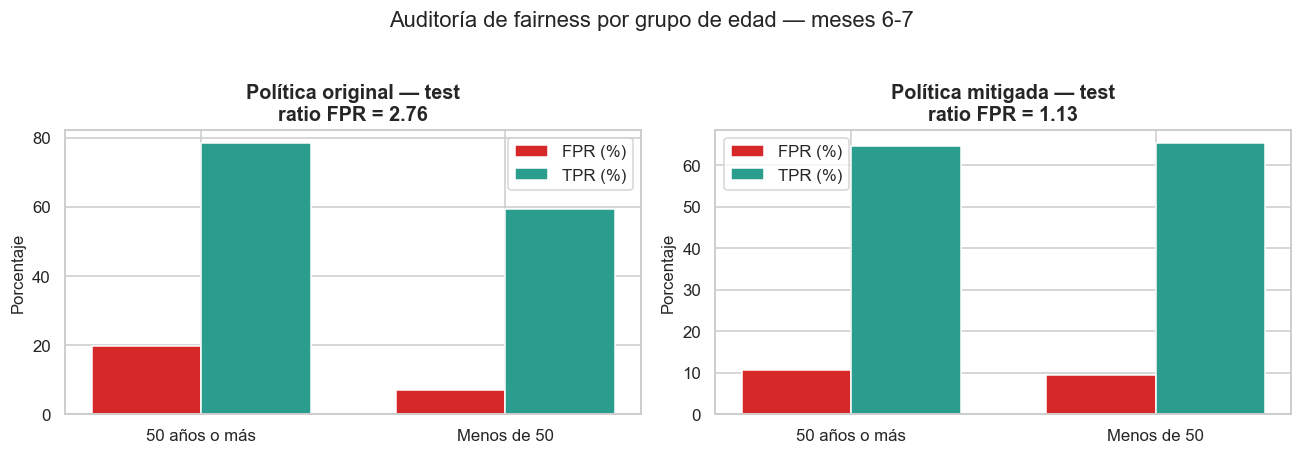

In [38]:
# Comparación gráfica de fairness en test:
# política original frente a política mitigada.

fig, ejes = plt.subplots(1, 2, figsize=(12, 4))

x = np.arange(len(tabla_grupos_test))
ancho = 0.36

# Política original

ejes[0].bar(
    x - ancho / 2,
    tabla_grupos_test['FPR_%'],
    width=ancho,
    color=COLOR_FRAUDE,
    label='FPR (%)'
)

ejes[0].bar(
    x + ancho / 2,
    tabla_grupos_test['TPR_%'],
    width=ancho,
    color=COLOR_LEGITIMO,
    label='TPR (%)'
)

ejes[0].set_xticks(x)
ejes[0].set_xticklabels(tabla_grupos_test['grupo'])
ejes[0].set_ylabel('Porcentaje')
ejes[0].set_title(
    f'Política original — test\n'
    f'ratio FPR = {disparidad_test:.2f}'
)
ejes[0].legend()

# Política mitigada

ejes[1].bar(
    x - ancho / 2,
    tabla_eq_test['FPR_%'],
    width=ancho,
    color=COLOR_FRAUDE,
    label='FPR (%)'
)

ejes[1].bar(
    x + ancho / 2,
    tabla_eq_test['TPR_%'],
    width=ancho,
    color=COLOR_LEGITIMO,
    label='TPR (%)'
)

ejes[1].set_xticks(x)
ejes[1].set_xticklabels(tabla_eq_test['grupo'])
ejes[1].set_ylabel('Porcentaje')
ejes[1].set_title(
    f'Política mitigada — test\n'
    f'ratio FPR = {disparidad_eq_test:.2f}'
)
ejes[1].legend()

fig.suptitle(
    'Auditoría de fairness por grupo de edad — meses 6-7',
    y=1.03
)

fig.tight_layout()

guardar_figura(
    fig,
    'fig_fairness_original_vs_mitigada'
)

plt.show()

In [39]:
# Prueba adicional con la Variante IV

# El modelo se entrena exclusivamente con los meses 0-4.
# El mes 5 se utiliza para fijar el punto de operación de la Variante IV,
# reproduciendo la misma proporción de alertas observada en la validación
# de la política principal.

# Los meses 6-7 permanecen reservados exclusivamente para evaluar
# discriminación y disparidad entre grupos.

with zipfile.ZipFile(RUTA_ZIPS / 'Variant IV.csv.zip') as z:
    z.extract('Variant IV.csv', RUTA_LOCAL)

df4 = construir_features(
    pd.read_csv(
        RUTA_LOCAL / 'Variant IV.csv',
        dtype=TIPOS_COLUMNAS
    )
)

tr4 = df4['month'] <= 4
v4_var = df4['month'] == 5
te4 = df4['month'] >= 6

X4_tr = df4.loc[tr4, predictoras]
y4_tr = df4.loc[tr4, 'fraud_bool']
X4_val = df4.loc[v4_var, predictoras]
X4_te = df4.loc[te4, predictoras]
y4_te = df4.loc[te4, 'fraud_bool'].to_numpy()

mayor4 = df4.loc[te4, 'customer_age'].to_numpy() >= 50
ratio4 = (y4_tr == 0).sum() / (y4_tr == 1).sum()

params4 = dict(mejores_params)
params4.update(
    scale_pos_weight=ratio4,
    subsample_freq=1,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)

pipe4 = Pipeline([
    ('pre', hacer_preproc()),
    ('modelo', LGBMClassifier(**params4))
]).fit(X4_tr, y4_tr)

p4_val = pipe4.predict_proba(X4_val)[:, 1]
p4_test = pipe4.predict_proba(X4_te)[:, 1]

# El punto de operación se fija exclusivamente con el mes 5,
# igualando la proporción de alertas de la política principal.

tasa_alertas_val = alerta_val_oper.mean()

u4 = float(
    np.quantile(
        p4_val,
        1 - tasa_alertas_val
    )
)

print(
    f'Tasa objetivo de alertas en validación: '
    f'{100 * tasa_alertas_val:.2f}%'
)

print(
    f'Umbral operativo Variante IV fijado en mes 5: '
    f'{u4:.4f}'
)

# El umbral congelado se aplica posteriormente al test.
al4 = p4_test >= u4

fpr_mayor = 100 * al4[(y4_te == 0) & mayor4].mean()
fpr_menor = 100 * al4[(y4_te == 0) & ~mayor4].mean()

print(f'AUC en test de la Variante IV: '
      f'{roc_auc_score(y4_te, p4_test):.4f} '
      f'(Base: {metricas_test["AUC"]:.4f})')

print(f'FPR grupo mayor: {fpr_mayor:.2f}% | '
      f'FPR grupo menor: {fpr_menor:.2f}% | '
      f'ratio {fpr_mayor/fpr_menor:.1f}')

del df4

Tasa objetivo de alertas en validación: 9.63%
Umbral operativo Variante IV fijado en mes 5: 0.5623
AUC en test de la Variante IV: 0.8590 (Base: 0.8891)
FPR grupo mayor: 16.66% | FPR grupo menor: 3.67% | ratio 4.5


### Análisis retrospectivo de la evolución temporal

Una vez finalizadas las decisiones de desarrollo, selección, calibración y
evaluación del sistema, se analiza retrospectivamente la evolución del
dataset completo. Este análisis no interviene en la selección de variables,
hiperparámetros ni umbrales, sino que permite caracterizar la deriva observada
a lo largo de los ocho periodos disponibles.

       solicitudes  tasa_fraude
month                          
0           132440       1.1330
1           127620       0.9390
2           136979       0.8750
3           150936       0.9220
4           127691       1.1370
5           119323       1.1830
6           108168       1.3410
7            96843       1.4750
Figura guardada: fig_14_evolucion_temporal_completa.png


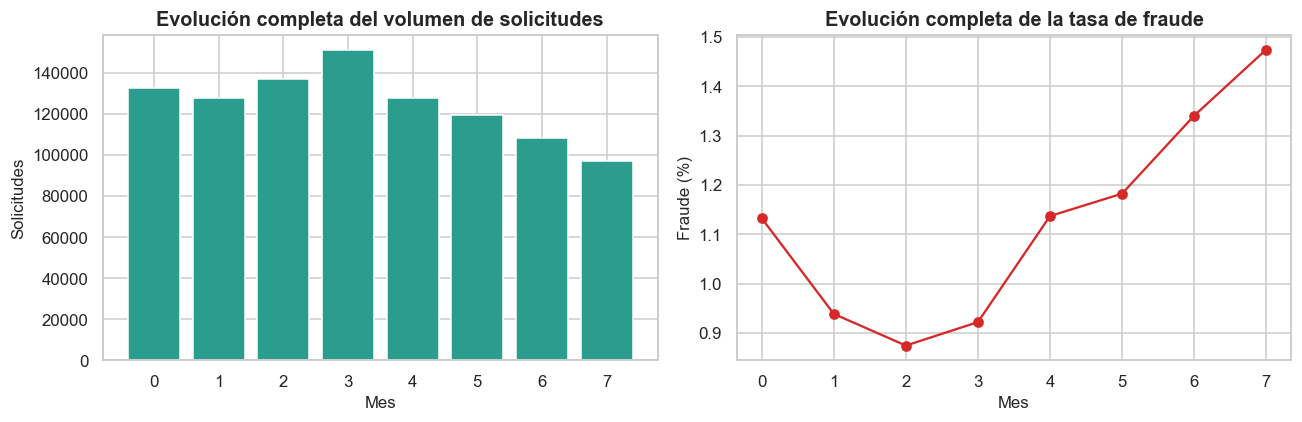

In [40]:
# Evolución temporal completa del dataset
# Análisis retrospectivo realizado una vez finalizada la evaluación.

mensual_completo = (
    df.groupby('month')
    .agg(
        solicitudes=('fraud_bool', 'size'),
        tasa_fraude=('fraud_bool', 'mean')
    )
)

mensual_completo['tasa_fraude'] *= 100

print(mensual_completo.round(3).to_string())

fig, ejes = plt.subplots(1, 2, figsize=(12, 4))

# Volumen mensual
ejes[0].bar(
    mensual_completo.index,
    mensual_completo['solicitudes'],
    color=COLOR_LEGITIMO
)

ejes[0].set_title('Evolución completa del volumen de solicitudes')
ejes[0].set_xlabel('Mes')
ejes[0].set_ylabel('Solicitudes')

# Tasa mensual de fraude
ejes[1].plot(
    mensual_completo.index,
    mensual_completo['tasa_fraude'],
    marker='o',
    color=COLOR_FRAUDE
)

ejes[1].set_title('Evolución completa de la tasa de fraude')
ejes[1].set_xlabel('Mes')
ejes[1].set_ylabel('Fraude (%)')

fig.tight_layout()

guardar_figura(
    fig,
    'fig_14_evolucion_temporal_completa'
)

plt.show()

## 9. Productivización

Hasta este punto, el modelo se ha desarrollado y evaluado dentro de Google Colab. Para poder utilizarlo fuera del notebook, en esta sección se guardan conjuntamente el preprocesador, el modelo, el calibrador, el umbral operativo y la información necesaria para reproducir la predicción.

También se genera un archivo `requirements.txt` con las librerías utilizadas y se prepara una API con FastAPI. Esta API recibe los datos de una solicitud en formato JSON y devuelve la probabilidad estimada de fraude, la decisión correspondiente, el coste esperado y los principales factores que influyeron en la predicción.

La ejecución del servicio se realizará fuera de Colab mediante Uvicorn.

In [41]:

codigo_api = '''
# CENTINELA - API para solicitudes de apertura de cuenta
# Ejecucion: uvicorn app:app --reload

from pathlib import Path
from typing import Literal

import joblib
import numpy as np
import pandas as pd
import shap

from fastapi import FastAPI
from pydantic import BaseModel, ConfigDict

RUTA_ARTEFACTO = Path(__file__).resolve().parents[1] / "modelos" / "centinela_v1.joblib"
ARTE = joblib.load(RUTA_ARTEFACTO)
EXPLICADOR = shap.TreeExplainer(ARTE["modelo"])


class Solicitud(BaseModel):
    model_config = ConfigDict(
        extra="forbid",
        allow_inf_nan=False
    )

    income: float
    name_email_similarity: float
    prev_address_months_count: int
    current_address_months_count: int
    customer_age: int
    days_since_request: float
    intended_balcon_amount: float
    payment_type: str
    zip_count_4w: int
    velocity_6h: float
    velocity_24h: float
    velocity_4w: float
    bank_branch_count_8w: int
    date_of_birth_distinct_emails_4w: int
    employment_status: str
    credit_risk_score: int
    email_is_free: Literal[0, 1]
    housing_status: str
    phone_home_valid: Literal[0, 1]
    phone_mobile_valid: Literal[0, 1]
    bank_months_count: int
    has_other_cards: Literal[0, 1]
    proposed_credit_limit: float
    foreign_request: Literal[0, 1]
    source: str
    session_length_in_minutes: float
    device_os: str
    keep_alive_session: Literal[0, 1]
    device_distinct_emails_8w: int


def construir_features(datos):
    d = datos.copy()

    d["velocity_6h"] = d["velocity_6h"].clip(lower=0)

    d["ratio_velocidad_6h_24h"] = (
        d["velocity_6h"] / d["velocity_24h"]
    ).astype("float32")

    d["ratio_velocidad_24h_4w"] = (
        d["velocity_24h"] / d["velocity_4w"]
    ).astype("float32")

    d["presion_zip"] = (
        d["zip_count_4w"] / d["velocity_4w"]
    ).astype("float32")

    for col in [
        "ratio_velocidad_6h_24h",
        "ratio_velocidad_24h_4w",
        "presion_zip"
    ]:
        d[col] = d[col].replace([np.inf, -np.inf], np.nan)

    d["telefonos_validos"] = (
        d["phone_home_valid"] + d["phone_mobile_valid"]
    ).astype("int8")

    d["similitud_baja"] = (
        d["name_email_similarity"] < 0.2
    ).astype("int8")

    d["limite_alto"] = (
        d["proposed_credit_limit"] >= 1500
    ).astype("int8")

    d["dispositivo_multiemail"] = (
        d["device_distinct_emails_8w"] >= 2
    ).astype("int8")

    ausencia = {
        "prev_address_months_count":
            d["prev_address_months_count"] == -1,

        "current_address_months_count":
            d["current_address_months_count"] == -1,

        "bank_months_count":
            d["bank_months_count"] == -1,

        "session_length_in_minutes":
            d["session_length_in_minutes"] == -1,

        "device_distinct_emails_8w":
            d["device_distinct_emails_8w"] == -1,

        "intended_balcon_amount":
            d["intended_balcon_amount"] < 0,
    }

    for col, falta in ausencia.items():
        d[col + "_ausente"] = falta.astype("int8")
        d[col] = d[col].astype("float32").where(~falta)

    flags = [c for c in d.columns if c.endswith("_ausente")]
    d["n_faltantes"] = d[flags].sum(axis=1).astype("int8")

    return d


app = FastAPI(
    title="CENTINELA",
    description="Decision de riesgo en apertura de cuentas",
    version="1.0"
)


@app.get("/salud")
def salud():
    return {
        "estado": "operativo",
        "modelo": "centinela_v1",
        "umbral_operativo": ARTE["umbral_operativo"],
        "entrenamiento": ARTE["esquema_temporal"]
    }


@app.post("/predecir")
def predecir(solicitud: Solicitud):
    datos = solicitud.model_dump()

    fila = construir_features(
        pd.DataFrame([datos])
    )[ARTE["columnas"]]

    X = ARTE["preprocesador"].transform(fila)

    prob = float(
        ARTE["calibrador"].predict(
            ARTE["modelo"].predict_proba(X)[:, 1]
        )[0]
    )

    decision = (
        "REVISION_MANUAL"
        if prob >= ARTE["umbral_operativo"]
        else "APROBACION"
    )

    contrib = pd.Series(
        EXPLICADOR(X).values[0],
        index=X.columns
    )

    top = contrib.sort_values(
        key=lambda s: s.abs(),
        ascending=False
    ).head(3)

    factores = [
        {
            "variable": k,
            "efecto": round(float(v), 3),
            "direccion": (
                "aumenta_riesgo"
                if v > 0
                else "reduce_riesgo"
            )
        }
        for k, v in top.items()
    ]

    exposicion = float(
        datos["proposed_credit_limit"]
    )

    return {
        "probabilidad_fraude": round(prob, 4),
        "decision": decision,
        "umbral_operativo": ARTE["umbral_operativo"],
        "exposicion_si_aprueba_usd": exposicion,
        "coste_esperado_si_aprueba_usd": round(
            prob * exposicion,
            2
        ),
        "coste_revision_usd": ARTE["coste_revision_$"],
        "factores_principales": factores,
    }
'''

In [42]:
# Generación del archivo de la API con FastAPI
# También se prepara un ejemplo para probar el servicio fuera de Colab.
ruta_api = RUTA_SALIDAS / 'api'
ruta_api.mkdir(exist_ok=True)

(ruta_api / 'app.py').write_text(
    codigo_api.strip() + '\n',
    encoding='utf-8'
)

print('API escrita en:', ruta_api / 'app.py')

# Se utiliza el caso explicado mediante SHAP como solicitud de ejemplo.
idx_original = X_te.index[pos_ejemplo]

campos_api = [
    c for c in df.columns
    if c not in ('fraud_bool', 'month', 'device_fraud_count')
]

ejemplo = {
    c: (v.item() if hasattr(v, 'item') else str(v))
    for c, v in df.loc[idx_original, campos_api].items()
}

(ruta_api / 'ejemplo_solicitud.json').write_text(
    json.dumps(ejemplo, indent=2),
    encoding='utf-8'
)

# Se comprueba que el archivo generado no tenga errores de sintaxis.
import py_compile

py_compile.compile(
    str(ruta_api / 'app.py'),
    doraise=True
)

print('app.py validado sin errores de sintaxis.')
print('Ejemplo guardado: ejemplo_solicitud.json')
print('\nPrueba desde la carpeta api/:')
print('  pip install -r ../requirements.txt')
print('  uvicorn app:app --reload')
print("  curl -X POST http://127.0.0.1:8000/predecir "
      "-H 'Content-Type: application/json' "
      "-d @ejemplo_solicitud.json")

API escrita en: c:\Users\KRONUS\Desktop\emilio-master\centinela-fraud-detection\outputs\api\app.py
app.py validado sin errores de sintaxis.
Ejemplo guardado: ejemplo_solicitud.json

Prueba desde la carpeta api/:
  pip install -r ../requirements.txt
  uvicorn app:app --reload
  curl -X POST http://127.0.0.1:8000/predecir -H 'Content-Type: application/json' -d @ejemplo_solicitud.json


In [43]:
# Guardado del modelo y de los elementos necesarios para utilizarlo

artefacto = {
    'preprocesador': pre_fit,
    'modelo': modelo_final,
    'calibrador': iso,
    'umbral_operativo': U_OPER,
    'coste_revision_$': C_REV,
    'columnas': predictoras,
    'categoricas': CATEG,
    'numericas': NUMER,
    'esquema_temporal': (
        'selección 0-3/4, entrenamiento 0-4, '
        'calibración 5, evaluación 6-7'
    ),
    'fecha_entrenamiento': datetime.now().strftime('%Y-%m-%d'),
    'metricas_test': {
        k: float(v)
        for k, v in metricas_test.items()
    },
}

ruta_modelo = RUTA_MODELOS / 'centinela_v1.joblib'
joblib.dump(artefacto, ruta_modelo)

print(f'Artefacto guardado: {ruta_modelo.name} '
      f'({ruta_modelo.stat().st_size / 1_048_576:.1f} MB)')

# Se comprueba todo el recorrido desde las variables originales del modelo.
art = joblib.load(ruta_modelo)
pos = pos_ejemplo

fila = X_te.iloc[[pos]]
fila_transformada = art['preprocesador'].transform(fila)

p_recarga = float(
    art['calibrador'].predict(
        art['modelo'].predict_proba(fila_transformada)[:, 1]
    )[0]
)

print(f'Verificación: prob. en memoria {p_cal[pos]:.6f} | '
      f'recargada {p_recarga:.6f}')

# Dependencias necesarias para reproducir el análisis y ejecutar la API.
LIBS = [
    'numpy',
    'pandas',
    'scipy',
    'scikit-learn',
    'lightgbm',
    'xgboost',
    'shap',
    'optuna',
    'joblib',
    'matplotlib',
    'seaborn',
    'fastapi',
    'pydantic',
    'uvicorn',
]

contenido = '\n'.join(
    f'{lib}=={version(lib)}'
    for lib in LIBS
)

(RUTA_SALIDAS / 'requirements.txt').write_text(
    contenido + '\n',
    encoding='utf-8'
)

print('requirements.txt escrito en outputs/.')

Artefacto guardado: centinela_v1.joblib (3.9 MB)
Verificación: prob. en memoria 0.056373 | recargada 0.056373
requirements.txt escrito en outputs/.


## 10. Conclusiones, limitaciones y líneas futuras

### Conclusiones

Los resultados muestran que el valor del modelo no depende únicamente de su capacidad para ordenar solicitudes según su riesgo. La calibración de las probabilidades y la selección del umbral permiten transformar esas puntuaciones en una decisión que considera tanto el coste de los fraudes no detectados como el esfuerzo necesario para revisar las alertas.

Con un objetivo de capacidad de 300 revisiones diarias, utilizado para
seleccionar y congelar el umbral operativo en el mes 5, el sistema detecta
aproximadamente dos tercios de los fraudes durante los meses de prueba. Al
aplicar el mismo umbral sin modificaciones a los meses 6 y 7, la carga
observada aumenta hasta aproximadamente 337 alertas diarias, lo que muestra
que los cambios en la distribución de los datos pueden afectar también a la
capacidad operativa necesaria.

La auditoría por grupos de edad también muestra que un buen resultado global no garantiza que el modelo trate de la misma forma a todos los solicitantes. La prueba realizada con la Variante IV confirma que las diferencias aprendidas durante el entrenamiento pueden mantenerse incluso cuando la distribución posterior cambia. Por esta razón, las métricas predictivas, económicas y de equidad deberían evaluarse conjuntamente.

### Limitaciones

La principal limitación es el carácter sintético del dataset. Aunque reproduce problemas habituales como el desbalanceo, la deriva temporal y las diferencias entre grupos, los resultados no deben interpretarse como una estimación directa del comportamiento de clientes o entidades financieras reales.

El modelo económico también utiliza supuestos simplificados. La pérdida de un fraude se aproxima a partir del límite de crédito solicitado y el coste de revisión se fija inicialmente en 10 dólares. El análisis de sensibilidad permite comprobar la estabilidad de los resultados, pero una aplicación real necesitaría estimar ambos valores con información contable y operativa de la entidad.

La calibración y la elección del umbral se basan en un único mes de validación. Con un periodo histórico más amplio sería conveniente utilizar varias ventanas temporales y comprobar con qué frecuencia deben actualizarse el calibrador y el umbral.

La auditoría de equidad se concentra en la edad y en la tasa de falsos positivos. Este análisis podría ampliarse a otras variables, siempre que su utilización sea legal y metodológicamente justificable, e incorporar métricas adicionales de aprobación, detección y coste por grupo.

Por último, el sistema analiza cada solicitud de manera individual. No incorpora relaciones entre dispositivos, correos, direcciones o redes de solicitudes coordinadas.

### Líneas futuras

Como continuación del proyecto se plantea validar el enfoque con datos reales y costes proporcionados por una institución financiera, ampliar la auditoría de equidad, incorporar un esquema de seguimiento temporal y definir una política de recalibración o reentrenamiento.

Otra línea relevante sería representar las relaciones entre solicitantes, dispositivos, direcciones e identificadores compartidos mediante técnicas basadas en grafos. Esto permitiría complementar la evaluación individual con la detección de posibles redes o ataques coordinados.